# Imports & Loading the data

In [1]:
#1 - Imports & paths
from pathlib import Path
import pandas as pd

ROOT = Path('/data0/b2ai-voice/2.0.0')
SPEC = ROOT / 'spectrogram.parquet'
PHEN = ROOT / 'phenotype.tsv'
print(SPEC.exists(), PHEN.exists())


True True


In [2]:
#2 - Load files (safe row-group read)
import pyarrow.parquet as pq

pheno = pd.read_csv(PHEN, sep='\t')

pf = pq.ParquetFile(SPEC)
parts = []
for i in range(pf.num_row_groups):
    parts.append(pf.read_row_group(i, columns=['participant_id','session_id','task_name','spectrogram']).to_pandas())
spec = pd.concat(parts, ignore_index=True)

print("pheno:", pheno.shape, "spec:", spec.shape)
spec.head(2)


pheno: (442, 1109) spec: (16738, 4)


,participant_id,session_id,task_name,spectrogram
0,004d42e9,07031CC3,Animal-fluency,"[[3.2496545, 0.8633412, 0.29140452, -15.261607..."
1,004d42e9,07031CC3,Cinderella-Story,"[[25.801548, 24.044765, 21.460907, 19.336544, ..."


In [3]:
#3 - Build PD label

# Maps “Checked/Unchecked” → 1/0.
pheno['parkinsons_label'] = pheno['parkinsons'].map({'Checked':1, 'Unchecked':0})
labels = pheno[['participant_id','parkinsons_label']].dropna()
labels['parkinsons_label'] = labels['parkinsons_label'].astype(int)
labels['parkinsons_label'].value_counts()


parkinsons_label
0    381
1     61
Name: count, dtype: int64

In [4]:
#4 - Merge

# Joins spectrograms with labels by participant_id.
data = spec.merge(labels, on='participant_id', how='inner')
print("merged:", data.shape)
data[['participant_id','session_id','task_name','parkinsons_label']].head(3)


merged: (16738, 5)


,participant_id,session_id,task_name,parkinsons_label
0,004d42e9,07031CC3,Animal-fluency,0
1,004d42e9,07031CC3,Cinderella-Story,0
2,004d42e9,07031CC3,Diadochokinesis-KA,0


# EDA

In [5]:
#5 - Inspect spectrogram structure (fixed)
import numpy as np

# We now know: 201 frequency bins × 3002 time frames (but stored as object array)
# Let's properly stack one sample and verify

sample = data['spectrogram'].iloc[0]
arr = np.stack(sample)  # Stack the 201 arrays into a proper 2D array
print(f"Single spectrogram shape: {arr.shape}")
print(f"Dtype: {arr.dtype}, Min: {arr.min():.2f}, Max: {arr.max():.2f}")

# Check a few more to confirm consistency
print("\n--- Checking 5 samples ---")
for i in range(5):
    s = data['spectrogram'].iloc[i]
    stacked = np.stack(s)
    print(f"Sample {i}: shape={stacked.shape}")

# Check shape distribution across all data
print("\n--- Shape distribution across dataset ---")
shapes = data['spectrogram'].apply(lambda x: (len(x), len(x[0])))
print(f"Unique shapes: {shapes.nunique()}")
print(shapes.value_counts().head(10))

Single spectrogram shape: (201, 3002)
Dtype: float32, Min: -33.99, Max: 46.01

--- Checking 5 samples ---
Sample 0: shape=(201, 3002)
Sample 1: shape=(201, 12225)
Sample 2: shape=(201, 214)
Sample 3: shape=(201, 197)
Sample 4: shape=(201, 434)

--- Shape distribution across dataset ---
Unique shapes: 2586
spectrogram
(201, 1502)    1274
(201, 607)      321
(201, 3002)     243
(201, 1501)     235
(201, 606)       69
(201, 3001)      40
(201, 255)       39
(201, 218)       39
(201, 187)       38
(201, 196)       38
Name: count, dtype: int64


Time dimension statistics:
  Min: 6
  Max: 16628
  Mean: 934.5
  Median: 597.0
  Std: 1087.7

Percentiles:
  25th: 297
  50th: 597
  75th: 1304
  90th: 1697
  95th: 3002
  99th: 4901


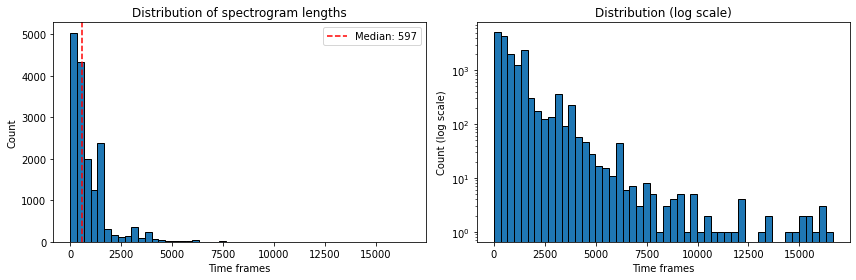


Total samples: 16738


In [6]:
#6 - Analyze time dimension distribution
import numpy as np
import matplotlib.pyplot as plt

# Extract time dimensions
time_dims = data['spectrogram'].apply(lambda x: len(x[0]))

print("Time dimension statistics:")
print(f"  Min: {time_dims.min()}")
print(f"  Max: {time_dims.max()}")
print(f"  Mean: {time_dims.mean():.1f}")
print(f"  Median: {time_dims.median():.1f}")
print(f"  Std: {time_dims.std():.1f}")

# Percentiles to guide truncation/padding decision
percentiles = [25, 50, 75, 90, 95, 99]
print("\nPercentiles:")
for p in percentiles:
    print(f"  {p}th: {np.percentile(time_dims, p):.0f}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(time_dims, bins=50, edgecolor='black')
axes[0].set_xlabel('Time frames')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of spectrogram lengths')
axes[0].axvline(time_dims.median(), color='r', linestyle='--', label=f'Median: {time_dims.median():.0f}')
axes[0].legend()

# Log scale for better visualization of spread
axes[1].hist(time_dims, bins=50, edgecolor='black', log=True)
axes[1].set_xlabel('Time frames')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Distribution (log scale)')

plt.tight_layout()
plt.savefig('time_distribution.png', dpi=150)
plt.show()

print(f"\nTotal samples: {len(time_dims)}")

In [7]:
#7 - Investigate short recordings and length vs label relationship
import numpy as np

# Add time dimension to dataframe for analysis
data['time_frames'] = data['spectrogram'].apply(lambda x: len(x[0]))

# Check very short recordings
short_threshold = 100
short_recordings = data[data['time_frames'] < short_threshold]
print(f"Recordings with < {short_threshold} frames: {len(short_recordings)}")
print(f"Their task distribution:\n{short_recordings['task_name'].value_counts()}")
print(f"Their PD label distribution:\n{short_recordings['parkinsons_label'].value_counts()}")

# Check if length correlates with PD status (potential bias)
print("\n--- Time frames by PD status ---")
for label in [0, 1]:
    subset = data[data['parkinsons_label'] == label]['time_frames']
    print(f"PD={label}: mean={subset.mean():.1f}, median={subset.median():.1f}, n={len(subset)}")

# Check task distribution overall
print("\n--- Task distribution ---")
print(data['task_name'].value_counts())

# Check task distribution by PD status
print("\n--- Tasks by PD status ---")
print(pd.crosstab(data['task_name'], data['parkinsons_label']))

Recordings with < 100 frames: 184
Their task distribution:
task_name
Respiration-and-cough-Breath-2               20
Respiration-and-cough-Cough-2                20
Respiration-and-cough-FiveBreaths-3          20
Respiration-and-cough-FiveBreaths-4          20
Respiration-and-cough-ThreeQuickBreaths-2    19
Free-speech-2                                12
Free-speech-3                                 8
Story-recall                                  8
Cape-V-sentences-2                            6
Cinderella-Story                              6
Free-speech-1                                 5
Cape-V-sentences-3                            4
Respiration-and-cough-Cough-1                 3
Cape-V-sentences-4                            3
Diadochokinesis-KA                            3
Diadochokinesis-TA                            3
Rainbow-Passage                               3
Loudness                                      2
Respiration-and-cough-Breath-1                2
Cape-V-sentences-6 

# Select HIGH PD-ratio tasks + process raw spectrograms + split + Visualization

In [8]:
#8 - Select HIGH PD-ratio tasks + process raw spectrograms + split
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split

print("="*75)
print("STRATEGY: Train ONLY on high PD-ratio tasks (56% PD)")
print("="*75)

# STEP 1: Select ONLY high PD-ratio tasks

high_pd_only_tasks = [
    'Cinderella-Story',           
    'Productive-Vocabulary-1',
    'Productive-Vocabulary-2',
    'Productive-Vocabulary-3',
    'Productive-Vocabulary-4',
    'Productive-Vocabulary-5',
    'Productive-Vocabulary-6',
    'Word-color-Stroop',          
    'Random-Item-Generation',
]

min_time_frames = 100
data_high_pd = data[
    (data['task_name'].isin(high_pd_only_tasks)) & 
    (data['time_frames'] >= min_time_frames)
].copy()

print(f"\n### High PD-ratio tasks only ###")
print(f"Total samples: {len(data_high_pd)}")
print(f"PD samples: {data_high_pd['parkinsons_label'].sum()}")
print(f"Non-PD samples: {(data_high_pd['parkinsons_label'] == 0).sum()}")
print(f"PD ratio: {data_high_pd['parkinsons_label'].mean():.2%}")

print(f"\nParticipants:")
print(f"  Total: {data_high_pd['participant_id'].nunique()}")
print(f"  PD: {data_high_pd[data_high_pd['parkinsons_label']==1]['participant_id'].nunique()}")
print(f"  Non-PD: {data_high_pd[data_high_pd['parkinsons_label']==0]['participant_id'].nunique()}")

print(f"\nSamples per task:")
print(data_high_pd['task_name'].value_counts())

# STEP 2: Process RAW spectrograms

print(f"\n### Processing RAW spectrograms ###")

TARGET_SEQ_LEN = 1024  # Longer sequence for these tasks

def process_spectrogram_raw(spec_raw, target_len=1024):
    """Process raw spectrogram with reflect padding."""
    spec = np.stack(spec_raw).astype(np.float32)
    n_mels, time_len = spec.shape
    
    if time_len < target_len:
        # Reflect padding (better than zero padding for spectrograms)
        pad_width = target_len - time_len
        spec = np.pad(spec, ((0, 0), (0, pad_width)), mode='reflect')
    elif time_len > target_len:
        # Center crop
        start = (time_len - target_len) // 2
        spec = spec[:, start:start + target_len]
    
    return spec

X_list = []
for idx, row in tqdm(data_high_pd.iterrows(), total=len(data_high_pd), desc="Processing"):
    processed = process_spectrogram_raw(row['spectrogram'], TARGET_SEQ_LEN)
    X_list.append(processed)

X_raw = np.stack(X_list)
y_raw = data_high_pd['parkinsons_label'].values
participants_raw = data_high_pd['participant_id'].values

print(f"\nProcessed shape: {X_raw.shape}")
print(f"Value range: [{X_raw.min():.2f}, {X_raw.max():.2f}]")

# STEP 3: Participant-level train/test split

unique_parts = np.unique(participants_raw)
part_labels = np.array([y_raw[participants_raw == p][0] for p in unique_parts])

print(f"\n### Participant Statistics ###")
print(f"Unique participants: {len(unique_parts)}")
print(f"PD participants: {part_labels.sum()}")
print(f"Non-PD participants: {(part_labels == 0).sum()}")

# Stratified split by participant
train_parts, test_parts = train_test_split(
    unique_parts, test_size=0.2, stratify=part_labels, random_state=42
)

train_mask = np.isin(participants_raw, train_parts)
test_mask = np.isin(participants_raw, test_parts)

X_train = X_raw[train_mask]
y_train = y_raw[train_mask]
parts_train = participants_raw[train_mask]

X_test = X_raw[test_mask]
y_test = y_raw[test_mask]
parts_test = participants_raw[test_mask]

print(f"\n### Train/Test Split ###")
print(f"Train: {len(X_train)} samples from {len(train_parts)} participants")
print(f"  PD: {y_train.sum()} ({y_train.mean():.1%})")
print(f"Test: {len(X_test)} samples from {len(test_parts)} participants")
print(f"  PD: {y_test.sum()} ({y_test.mean():.1%})")

# Verify no participant overlap
assert len(set(train_parts) & set(test_parts)) == 0, "Data leakage detected!"
print(f"\n✓ No participant overlap between train and test sets")


STRATEGY: Train ONLY on high PD-ratio tasks (56% PD)

### High PD-ratio tasks only ###
Total samples: 1349
PD samples: 757
Non-PD samples: 592
PD ratio: 56.12%

Participants:
  Total: 112
  PD: 59
  Non-PD: 53

Samples per task:
task_name
Productive-Vocabulary-4    151
Word-color-Stroop          151
Productive-Vocabulary-3    151
Productive-Vocabulary-5    151
Productive-Vocabulary-1    150
Productive-Vocabulary-6    150
Productive-Vocabulary-2    150
Random-Item-Generation     150
Cinderella-Story           145
Name: count, dtype: int64

### Processing RAW spectrograms ###


Processing: 100%|██████████| 1349/1349 [00:01<00:00, 1215.36it/s]



Processed shape: (1349, 201, 1024)
Value range: [-100.00, 46.02]

### Participant Statistics ###
Unique participants: 112
PD participants: 59
Non-PD participants: 53

### Train/Test Split ###
Train: 1133 samples from 89 participants
  PD: 640 (56.5%)
Test: 216 samples from 23 participants
  PD: 117 (54.2%)

✓ No participant overlap between train and test sets


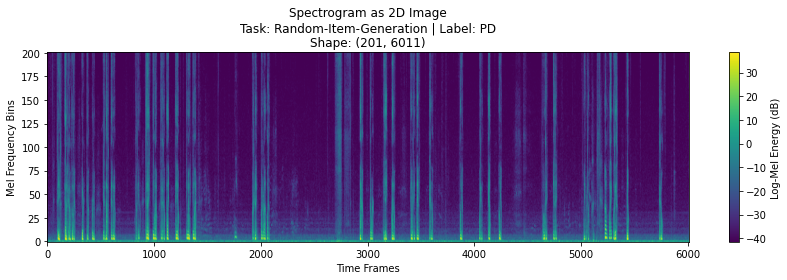

X-axis (horizontal): Time progression →
Y-axis (vertical): Frequency (low to high) ↑
Color intensity: Energy/loudness at that time-frequency point

AST treats this 2D image like a photo, splitting into 16×16 patches.


In [35]:
# Visualize spectrogram as 2D image representation
import matplotlib.pyplot as plt
import numpy as np

# Get one sample
sample_idx = 52
spec_sample = np.stack(data_high_pd.iloc[sample_idx]['spectrogram'])
task_name = data_high_pd.iloc[sample_idx]['task_name']
label = data_high_pd.iloc[sample_idx]['parkinsons_label']

fig, ax = plt.subplots(figsize=(12, 4))

img = ax.imshow(spec_sample, aspect='auto', origin='lower', cmap='viridis')
ax.set_xlabel('Time Frames')
ax.set_ylabel('Mel Frequency Bins')
ax.set_title(f'Spectrogram as 2D Image\nTask: {task_name} | Label: {"PD" if label==1 else "Non-PD"}\nShape: {spec_sample.shape}')
plt.colorbar(img, ax=ax, label='Log-Mel Energy (dB)')

plt.tight_layout()
plt.savefig('spectrogram_visualization.png', dpi=150)
plt.show()

print("X-axis (horizontal): Time progression →")
print("Y-axis (vertical): Frequency (low to high) ↑")
print("Color intensity: Energy/loudness at that time-frequency point")
print("\nAST treats this 2D image like a photo, splitting into 16×16 patches.")

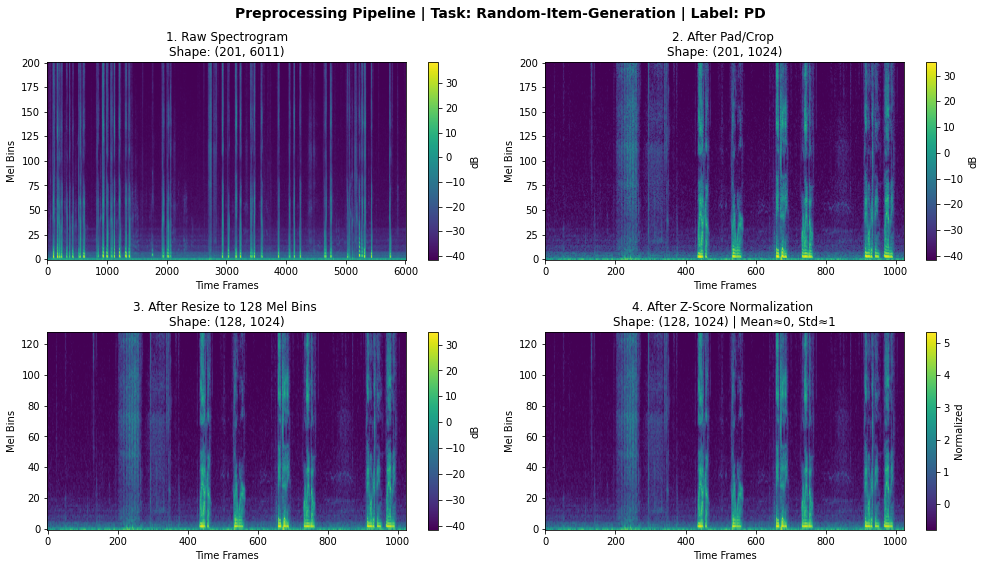

Preprocessing Summary:
  Raw:        (201, 6011) → Variable time length
  Pad/Crop:   (201, 1024) → Fixed 1024 time frames
  Resize:     (128, 1024) → 128 mel bins for AST
  Normalize:  (128, 1024) → Mean=0, Std=1


In [37]:
# Visualize spectrogram before and after preprocessing
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom

# Get one sample
sample_idx = 52
raw_spec = np.stack(data_high_pd.iloc[sample_idx]['spectrogram'])
task_name = data_high_pd.iloc[sample_idx]['task_name']
label = "PD" if data_high_pd.iloc[sample_idx]['parkinsons_label'] == 1 else "Non-PD"

# Step 1: Pad/Crop to 1024 (Cell #8 preprocessing)
def preprocess_step1(spec, target_len=1024):
    n_mels, time_len = spec.shape
    if time_len < target_len:
        spec = np.pad(spec, ((0, 0), (0, target_len - time_len)), mode='reflect')
    elif time_len > target_len:
        start = (time_len - target_len) // 2
        spec = spec[:, start:start + target_len]
    return spec

# Step 2: Resize to 128 mel bins (Cell #9 preprocessing)
def preprocess_step2(spec, target_mel=128, target_time=1024):
    mel_ratio = target_mel / spec.shape[0]
    time_ratio = target_time / spec.shape[1]
    return zoom(spec, (mel_ratio, time_ratio), order=1)

# Step 3: Normalize (Cell #9 preprocessing)
def preprocess_step3(spec, mean, std):
    return (spec - mean) / (std + 1e-8)

# Apply preprocessing steps
step1_spec = preprocess_step1(raw_spec.copy())
step2_spec = preprocess_step2(step1_spec.copy())
step3_spec = preprocess_step3(step2_spec.copy(), step2_spec.mean(), step2_spec.std())

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Raw spectrogram
ax1 = axes[0, 0]
im1 = ax1.imshow(raw_spec, aspect='auto', origin='lower', cmap='viridis')
ax1.set_title(f'1. Raw Spectrogram\nShape: {raw_spec.shape}')
ax1.set_xlabel('Time Frames')
ax1.set_ylabel('Mel Bins')
plt.colorbar(im1, ax=ax1, label='dB')

# After pad/crop
ax2 = axes[0, 1]
im2 = ax2.imshow(step1_spec, aspect='auto', origin='lower', cmap='viridis')
ax2.set_title(f'2. After Pad/Crop \nShape: {step1_spec.shape}')
ax2.set_xlabel('Time Frames')
ax2.set_ylabel('Mel Bins')
plt.colorbar(im2, ax=ax2, label='dB')

# After resize
ax3 = axes[1, 0]
im3 = ax3.imshow(step2_spec, aspect='auto', origin='lower', cmap='viridis')
ax3.set_title(f'3. After Resize to 128 Mel Bins \nShape: {step2_spec.shape}')
ax3.set_xlabel('Time Frames')
ax3.set_ylabel('Mel Bins')
plt.colorbar(im3, ax=ax3, label='dB')

# After normalization
ax4 = axes[1, 1]
im4 = ax4.imshow(step3_spec, aspect='auto', origin='lower', cmap='viridis')
ax4.set_title(f'4. After Z-Score Normalization \nShape: {step3_spec.shape} | Mean≈0, Std≈1')
ax4.set_xlabel('Time Frames')
ax4.set_ylabel('Mel Bins')
plt.colorbar(im4, ax=ax4, label='Normalized')

plt.suptitle(f'Preprocessing Pipeline | Task: {task_name} | Label: {label}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing_pipeline.png', dpi=150)
plt.show()

print("Preprocessing Summary:")
print(f"  Raw:        {raw_spec.shape} → Variable time length")
print(f"  Pad/Crop:   {step1_spec.shape} → Fixed 1024 time frames")
print(f"  Resize:     {step2_spec.shape} → 128 mel bins for AST")
print(f"  Normalize:  {step3_spec.shape} → Mean=0, Std=1")

In [9]:
# List of your selected high-PD-prevalence tasks
selected_tasks = [
    "Cinderella-Story",
    "Productive-Vocabulary-1",
    "Productive-Vocabulary-2",
    "Productive-Vocabulary-3",
    "Productive-Vocabulary-4",
    "Productive-Vocabulary-5",
    "Productive-Vocabulary-6",
    "Random-Item-Generation",
    "Animal-fluency"
]

# Filter data to selected tasks
subset = data[data["task_name"].isin(selected_tasks)]

# Count unique participants by label
subset_counts = subset.groupby("parkinsons_label")["participant_id"].nunique()
print(subset_counts)

# Optional: print numbers clearly
print(f"Non PD participants: {subset_counts.get(0, 0)}")
print(f"PD participants: {subset_counts.get(1, 0)}")


parkinsons_label
0    112
1     59
Name: participant_id, dtype: int64
Non PD participants: 112
PD participants: 59


# Modelling

In [10]:
#9 - Audio Spectrogram Transformer (AST) with pre-trained weights
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from transformers import ASTModel, ASTConfig
from tqdm import tqdm
from scipy.ndimage import zoom

print("="*75)
print("AUDIO SPECTROGRAM TRANSFORMER (AST) WITH PRETRAINED WEIGHTS")
print("="*75)

# STEP 1: Resize spectrograms for AST format

# AST expects 128 mel bins, we have 201 mel bins
def resize_spectrogram(spec, target_mel=128, target_time=1024):
    """Resize spectrogram to AST expected dimensions."""
    current_mel, current_time = spec.shape
    mel_ratio = target_mel / current_mel
    time_ratio = target_time / current_time
    resized = zoom(spec, (mel_ratio, time_ratio), order=1)
    return resized.astype(np.float32)

print("Resizing spectrograms for AST (128 mel bins, 1024 time frames)...")

X_train_ast = []
for i in tqdm(range(len(X_train)), desc="Train"):
    resized = resize_spectrogram(X_train[i], target_mel=128, target_time=1024)
    X_train_ast.append(resized)
X_train_ast = np.stack(X_train_ast)

X_test_ast = []
for i in tqdm(range(len(X_test)), desc="Test"):
    resized = resize_spectrogram(X_test[i], target_mel=128, target_time=1024)
    X_test_ast.append(resized)
X_test_ast = np.stack(X_test_ast)

print(f"\nResized shapes:")
print(f"  Train: {X_train_ast.shape}")
print(f"  Test: {X_test_ast.shape}")

# Normalize
ast_mean = X_train_ast.mean()
ast_std = X_train_ast.std()
X_train_ast_norm = (X_train_ast - ast_mean) / (ast_std + 1e-8)
X_test_ast_norm = (X_test_ast - ast_mean) / (ast_std + 1e-8)

print(f"Normalized - Train: mean={X_train_ast_norm.mean():.4f}, std={X_train_ast_norm.std():.4f}")

# STEP 2: AST Classifier model

class ASTClassifier(nn.Module):
    """AST-based classifier using pre-trained weights."""
    def __init__(self, num_classes=2, pretrained=True, freeze_base=False):
        super().__init__()
        
        if pretrained:
            print("Loading pre-trained AST model...")
            self.ast = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
            hidden_size = self.ast.config.hidden_size  # 768
        else:
            config = ASTConfig(
                hidden_size=768,
                num_hidden_layers=12,
                num_attention_heads=12,
                intermediate_size=3072,
                max_length=1024,
                num_mel_bins=128,
            )
            self.ast = ASTModel(config)
            hidden_size = 768
        
        if freeze_base:
            for param in self.ast.parameters():
                param.requires_grad = False
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        # x: (batch, 128, 1024) -> transpose to (batch, 1024, 128)
        x = x.transpose(1, 2)
        outputs = self.ast(input_values=x)
        pooled = outputs.pooler_output
        logits = self.classifier(pooled)
        return logits

# STEP 3: Dataset and DataLoaders

class ASTDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, participants, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.participants = np.array(participants)
        self.augment = augment
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        x = self.X[idx].clone()
        
        if self.augment:
            # Time mask
            if np.random.random() < 0.5:
                t = np.random.randint(50, 150)
                t0 = np.random.randint(0, max(1, x.shape[1] - t))
                x[:, t0:t0+t] = 0
            # Frequency mask
            if np.random.random() < 0.5:
                f = np.random.randint(10, 30)
                f0 = np.random.randint(0, max(1, x.shape[0] - f))
                x[f0:f0+f, :] = 0
        
        return {
            'inputs': x,
            'labels': self.y[idx],
            'participant': self.participants[idx]
        }

train_ds_ast = ASTDataset(X_train_ast_norm, y_train, parts_train, augment=True)
test_ds_ast = ASTDataset(X_test_ast_norm, y_test, parts_test, augment=False)

# Balanced sampler
class_counts = np.bincount(y_train)
weights = 1.0 / class_counts
sample_weights = weights[y_train]
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))

BATCH_SIZE = 8

train_loader_ast = torch.utils.data.DataLoader(
    train_ds_ast, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True
)
test_loader_ast = torch.utils.data.DataLoader(
    test_ds_ast, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)

print(f"\nDataLoaders: Train={len(train_loader_ast)} batches, Test={len(test_loader_ast)} batches")

# STEP 4: Initialize model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model_ast = ASTClassifier(num_classes=2, pretrained=True, freeze_base=False).to(device)

total_params = sum(p.numel() for p in model_ast.parameters())
trainable_params = sum(p.numel() for p in model_ast.parameters() if p.requires_grad)
print(f"\nAST Model:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# Test forward pass
with torch.no_grad():
    test_batch = next(iter(train_loader_ast))
    test_input = test_batch['inputs'].to(device)
    test_output = model_ast(test_input)
    print(f"  Forward pass: {test_input.shape} -> {test_output.shape}")

print("\n✓ AST model ready!")

AUDIO SPECTROGRAM TRANSFORMER (AST) WITH PRETRAINED WEIGHTS
Resizing spectrograms for AST (128 mel bins, 1024 time frames)...


Test: 100%|██████████| 216/216 [00:00<00:00, 451.40it/s]



Resized shapes:
  Train: (1133, 128, 1024)
  Test: (216, 128, 1024)
Normalized - Train: mean=-0.0000, std=1.0000

DataLoaders: Train=142 batches, Test=27 batches
Device: cuda
Loading pre-trained AST model...

AST Model:
  Total parameters: 86,386,178
  Trainable parameters: 86,386,178
  Forward pass: torch.Size([8, 128, 1024]) -> torch.Size([8, 2])

✓ AST model ready!


In [11]:
# #10 - Train pre-trained AST (PD Selected Tasks)
# class weights computed dynamically from y_train
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, roc_curve
from tqdm import tqdm
import copy
import time

def get_optimizer_groups(model, lr_backbone=1e-5, lr_head=1e-4, weight_decay=0.01):
    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if 'classifier' in name:
            head_params.append(param)
        else:
            backbone_params.append(param)
    return [
        {'params': backbone_params, 'lr': lr_backbone, 'weight_decay': weight_decay},
        {'params': head_params, 'lr': lr_head, 'weight_decay': weight_decay}
    ]

optimizer = torch.optim.AdamW(
    get_optimizer_groups(model_ast, lr_backbone=5e-6, lr_head=5e-4),
    betas=(0.9, 0.999)
)

NUM_EPOCHS = 50
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

# CHANGED: dynamic class weights (was hardcoded [0.56, 0.44])
cc = np.bincount(y_train)
cw = (cc.sum() / (2.0 * cc)).astype(np.float32)
class_weights = torch.tensor(cw, dtype=torch.float32).to(device)
print(f"Class weights: {cw} (computed from y_train: {cc})")
criterion = FocalLoss(alpha=class_weights, gamma=2.0)

def evaluate_ast(model, loader, device):
    model.eval()
    all_probs, all_labels, all_parts = [], [], []
    with torch.no_grad():
        for batch in loader:
            inputs = batch['inputs'].to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(batch['labels'].numpy())
            all_parts.extend(batch['participant'])

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_parts = np.array(all_parts)

    unique_parts = np.unique(all_parts)
    part_probs, part_labels = [], []
    for p in unique_parts:
        mask = all_parts == p
        part_probs.append(all_probs[mask].mean())
        part_labels.append(all_labels[mask][0])

    part_probs = np.array(part_probs)
    part_labels = np.array(part_labels)

    if len(np.unique(part_labels)) > 1:
        part_auc = roc_auc_score(part_labels, part_probs)
        fpr, tpr, thresholds = roc_curve(part_labels, part_probs)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_thresh = thresholds[optimal_idx]
    else:
        part_auc = 0.5
        optimal_thresh = 0.5

    part_preds = (part_probs >= 0.5).astype(int)
    part_preds_opt = (part_probs >= optimal_thresh).astype(int)

    return {
        'part_auc': part_auc,
        'part_f1': f1_score(part_labels, part_preds, zero_division=0),
        'part_f1_opt': f1_score(part_labels, part_preds_opt, zero_division=0),
        'part_recall_opt': recall_score(part_labels, part_preds_opt, zero_division=0),
        'part_prec_opt': precision_score(part_labels, part_preds_opt, zero_division=0),
        'optimal_thresh': optimal_thresh,
        'part_probs': part_probs,
        'part_labels': part_labels
    }

best_f1 = 0.0
best_auc = 0.0
best_model_state = None
best_epoch = 0
best_metrics = None
patience = 15
patience_counter = 0

print(f"Training AST | Epochs: {NUM_EPOCHS}, Patience: {patience}")
print(f"Train: {len(train_ds_ast)} samples ({y_train.mean():.1%} PD)")
print(f"Test: {len(test_ds_ast)} samples ({y_test.mean():.1%} PD)")
print(f"Backbone LR: 5e-6, Head LR: 5e-4\n")

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model_ast.train()
    total_loss = 0

    for batch in tqdm(train_loader_ast, desc=f'Epoch {epoch+1:02d}', leave=False):
        inputs = batch['inputs'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model_ast(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ast.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()
    avg_loss = total_loss / len(train_loader_ast)

    metrics = evaluate_ast(model_ast, test_loader_ast, device)

    score = 0.4 * metrics['part_auc'] + 0.6 * metrics['part_f1_opt']
    best_combined = 0.4 * best_auc + 0.6 * best_f1

    if score > best_combined + 0.01:
        best_f1 = metrics['part_f1_opt']
        best_auc = metrics['part_auc']
        best_model_state = copy.deepcopy(model_ast.state_dict())
        best_epoch = epoch + 1
        best_metrics = metrics.copy()
        patience_counter = 0
        marker = "<-- best"
    else:
        patience_counter += 1
        marker = ""

    lr_backbone = optimizer.param_groups[0]['lr']
    lr_head = optimizer.param_groups[1]['lr']

    print(f"Epoch {epoch+1:02d} | loss {avg_loss:.4f} | "
          f"AUC {metrics['part_auc']:.3f} | F1@0.5 {metrics['part_f1']:.3f} | "
          f"F1opt {metrics['part_f1_opt']:.3f} | rec {metrics['part_recall_opt']:.3f} | "
          f"prec {metrics['part_prec_opt']:.3f} | thr {metrics['optimal_thresh']:.3f} | "
          f"lr {lr_backbone:.1e}/{lr_head:.1e} {marker}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

elapsed = time.time() - start_time
model_ast.load_state_dict(best_model_state)

# save preliminary model
torch.save(best_model_state, "ast_pd_selected_preliminary.pt")
print(f"\nSaved: ast_pd_selected_preliminary.pt")

print(f"\nTraining done in {elapsed/60:.1f} minutes, best epoch: {best_epoch}")
print(f"AUC: {best_metrics['part_auc']:.4f}")
print(f"F1@0.5: {best_metrics['part_f1']:.4f}")
print(f"F1opt: {best_metrics['part_f1_opt']:.4f} (threshold={best_metrics['optimal_thresh']:.3f})")
print(f"Recall: {best_metrics['part_recall_opt']:.4f}")
print(f"Precision: {best_metrics['part_prec_opt']:.4f}")

Class weights: [1.1490872 0.8851563] (computed from y_train: [493 640])
Training AST | Epochs: 50, Patience: 15
Train: 1133 samples (56.5% PD)
Test: 216 samples (54.2% PD)
Backbone LR: 5e-6, Head LR: 5e-4



Epoch 01 | loss 0.1830 | AUC 0.432 | F1@0.5 0.381 | F1opt 0.286 | rec 0.167 | prec 1.000 | thr 0.643 | lr 5.0e-06/5.0e-04 <-- best


Epoch 02 | loss 0.1564 | AUC 0.545 | F1@0.5 0.143 | F1opt 0.471 | rec 0.333 | prec 0.800 | thr 0.448 | lr 5.0e-06/5.0e-04 <-- best


Epoch 03 | loss 0.1211 | AUC 0.591 | F1@0.5 0.571 | F1opt 0.692 | rec 0.750 | prec 0.643 | thr 0.383 | lr 5.0e-06/5.0e-04 <-- best


Epoch 04 | loss 0.0899 | AUC 0.591 | F1@0.5 0.353 | F1opt 0.667 | rec 0.750 | prec 0.600 | thr 0.240 | lr 4.9e-06/4.9e-04 


...

Epoch 23 | loss 0.0157 | AUC 0.689 | F1@0.5 0.571 | F1opt 0.720 | rec 0.750 | prec 0.692 | thr 0.390 | lr 2.9e-06/2.8e-04 


Epoch 24 | loss 0.0217 | AUC 0.659 | F1@0.5 0.714 | F1opt 0.588 | rec 0.417 | prec 1.000 | thr 0.900 | lr 2.7e-06/2.7e-04 


Epoch 25 | loss 0.0086 | AUC 0.705 | F1@0.5 0.571 | F1opt 0.588 | rec 0.417 | prec 1.000 | thr 0.711 | lr 2.6e-06/2.5e-04 


Epoch 26 | loss 0.0041 | AUC 0.788 | F1@0.5 0.741 | F1opt 0.762 | rec 0.667 | prec 0.889 | thr 0.611 | lr 2.4e-06/2.3e-04 


Epoch 27 | loss 0.0079 | AUC 0.712 | F1@0.5 0.667 | F1opt 0.700 | rec 0.583 | prec 0.875 | thr 0.568 | lr 2.2e-06/2.2e-04 
Early stopping at epoch 27

Saved: ast_pd_selected_preliminary.pt

Training done in 46.4 minutes, best epoch: 12
AUC: 0.7955
F1@0.5: 0.5556
F1opt: 0.8182 (threshold=0.423)
Recall: 0.7500
Precision: 0.9000


In [11]:
# #11 - 5-Fold Cross-Validation with AST (PD Selected Tasks)
# CHANGED from original:
#   1. Class weights: dynamic per fold via cc.sum()/(2*cc)
#   2. np.std uses ddof=1 everywhere (sample SD)
#   3. Saves fold models, OOF predictions, normalization stats, fold results
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, roc_curve
from scipy.ndimage import zoom
from tqdm import tqdm
import copy
import time

# participant-level setup
unique_participants = np.unique(participants_raw)
participant_labels = np.array([y_raw[participants_raw == p][0] for p in unique_participants])

print(f"Total participants: {len(unique_participants)}")
print(f"PD: {int(participant_labels.sum())} ({participant_labels.mean():.1%})")
print(f"Non-PD: {int((participant_labels == 0).sum())}")

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_results = []
all_oof_probs = np.zeros(len(unique_participants), dtype=np.float32)
all_oof_labels = participant_labels.astype(np.int64).copy()
norm_stats = {}  # save per-fold normalization for reproducibility

# helpers (same as original)
def resize_spectrogram_cv(spec, target_mel=128, target_time=1024):
    current_mel, current_time = spec.shape
    mel_ratio = target_mel / current_mel
    time_ratio = target_time / current_time
    resized = zoom(spec, (mel_ratio, time_ratio), order=1)
    return resized.astype(np.float32)

class ASTDatasetCV(torch.utils.data.Dataset):
    def __init__(self, X, y, participants, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.participants = np.array(participants)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            if np.random.random() < 0.5:
                t = np.random.randint(50, 150)
                t0 = np.random.randint(0, max(1, x.shape[1] - t))
                x[:, t0:t0+t] = 0
            if np.random.random() < 0.5:
                f = np.random.randint(10, 30)
                f0 = np.random.randint(0, max(1, x.shape[0] - f))
                x[f0:f0+f, :] = 0
        return {'inputs': x, 'labels': self.y[idx], 'participant': self.participants[idx]}

class FocalLossCV(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

def evaluate_fold(model, loader, device):
    model.eval()
    all_probs, all_labels, all_parts = [], [], []
    with torch.no_grad():
        for batch in loader:
            inputs = batch['inputs'].to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(batch['labels'].numpy())
            all_parts.extend(batch['participant'])

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_parts = np.array(all_parts)

    unique_parts = np.unique(all_parts)
    part_probs, part_labels = [], []
    for p in unique_parts:
        mask = all_parts == p
        part_probs.append(all_probs[mask].mean())
        part_labels.append(all_labels[mask][0])

    return np.array(part_probs), np.array(part_labels), unique_parts


# CV loop
total_start = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(unique_participants, participant_labels)):
    print(f"\n--- Fold {fold+1}/{N_FOLDS} ---")

    train_parts_fold = unique_participants[train_idx]
    val_parts_fold = unique_participants[val_idx]

    train_mask = np.isin(participants_raw, train_parts_fold)
    val_mask = np.isin(participants_raw, val_parts_fold)

    X_train_fold = X_raw[train_mask]
    y_train_fold = y_raw[train_mask]
    parts_train_fold = participants_raw[train_mask]

    X_val_fold = X_raw[val_mask]
    y_val_fold = y_raw[val_mask]
    parts_val_fold = participants_raw[val_mask]

    print(f"Train: {len(X_train_fold)} recordings from {len(train_parts_fold)} participants")
    print(f"Val: {len(X_val_fold)} recordings from {len(val_parts_fold)} participants")

    # resize
    X_train_ast_fold = np.stack([resize_spectrogram_cv(x) for x in tqdm(X_train_fold, desc="resize train", leave=False)])
    X_val_ast_fold = np.stack([resize_spectrogram_cv(x) for x in tqdm(X_val_fold, desc="resize val", leave=False)])

    # normalize on fold-specific training data
    fold_mean = X_train_ast_fold.mean()
    fold_std = X_train_ast_fold.std()
    X_train_ast_fold = (X_train_ast_fold - fold_mean) / (fold_std + 1e-8)
    X_val_ast_fold = (X_val_ast_fold - fold_mean) / (fold_std + 1e-8)
    norm_stats[fold + 1] = {'mean': float(fold_mean), 'std': float(fold_std)}

    # datasets
    train_ds_fold = ASTDatasetCV(X_train_ast_fold, y_train_fold, parts_train_fold, augment=True)
    val_ds_fold = ASTDatasetCV(X_val_ast_fold, y_val_fold, parts_val_fold, augment=False)

    # balanced sampler
    class_counts = np.bincount(y_train_fold)
    weights = 1.0 / class_counts
    sample_weights = weights[y_train_fold]
    sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))

    train_loader_fold = torch.utils.data.DataLoader(train_ds_fold, batch_size=8, sampler=sampler, num_workers=4, pin_memory=True)
    val_loader_fold = torch.utils.data.DataLoader(val_ds_fold, batch_size=8, shuffle=False, num_workers=4, pin_memory=True)

    # fresh model
    model_fold = ASTClassifier(num_classes=2, pretrained=True, freeze_base=False).to(device)

    backbone_params = [p for n, p in model_fold.named_parameters() if 'classifier' not in n]
    head_params = [p for n, p in model_fold.named_parameters() if 'classifier' in n]
    optimizer_fold = torch.optim.AdamW([
        {'params': backbone_params, 'lr': 5e-6, 'weight_decay': 0.01},
        {'params': head_params, 'lr': 5e-4, 'weight_decay': 0.01}
    ])
    scheduler_fold = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fold, T_max=30, eta_min=1e-7)

    # CHANGED: dynamic class weights for this fold
    cc = np.bincount(y_train_fold)
    cw = (cc.sum() / (2.0 * cc)).astype(np.float32)
    class_weights_fold = torch.tensor(cw, dtype=torch.float32).to(device)
    criterion_fold = FocalLossCV(alpha=class_weights_fold, gamma=2.0)
    print(f"Class weights: {cw} (from fold counts: {cc})")

    # training
    best_score_fold = 0
    best_state_fold = None
    patience_fold = 10
    patience_counter_fold = 0

    for epoch in range(30):
        model_fold.train()
        total_loss = 0
        for batch in train_loader_fold:
            inputs = batch['inputs'].to(device)
            labels = batch['labels'].to(device)
            optimizer_fold.zero_grad()
            outputs = model_fold(inputs)
            loss = criterion_fold(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_fold.parameters(), 1.0)
            optimizer_fold.step()
            total_loss += loss.item()

        scheduler_fold.step()

        # evaluate
        part_probs, part_labels, _ = evaluate_fold(model_fold, val_loader_fold, device)

        if len(np.unique(part_labels)) > 1:
            auc = roc_auc_score(part_labels, part_probs)
            fpr, tpr, thresholds = roc_curve(part_labels, part_probs)
            opt_idx = np.argmax(tpr - fpr)
            opt_thresh = thresholds[opt_idx]
            preds_opt = (part_probs >= opt_thresh).astype(int)
            f1_opt = f1_score(part_labels, preds_opt, zero_division=0)
        else:
            auc, f1_opt = 0.5, 0.0

        score = 0.4 * auc + 0.6 * f1_opt
        if score > best_score_fold + 0.01:
            best_score_fold = score
            best_state_fold = copy.deepcopy(model_fold.state_dict())
            patience_counter_fold = 0
        else:
            patience_counter_fold += 1

        if patience_counter_fold >= patience_fold:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    # load best and get final predictions
    model_fold.load_state_dict(best_state_fold)
    part_probs, part_labels, val_pids = evaluate_fold(model_fold, val_loader_fold, device)

    # save fold model
    torch.save(model_fold.state_dict(), f"ast_pd_selected_fold{fold+1}.pt")

    # store OOF predictions
    for i, pid in enumerate(val_pids):
        idx = np.where(unique_participants == pid)[0][0]
        all_oof_probs[idx] = part_probs[i]
cc.sum() / (2.0 * cc)
    # fold metrics
    fold_auc = roc_auc_score(part_labels, part_probs)
    fpr, tpr, thresholds = roc_curve(part_labels, part_probs)
    opt_idx = np.argmax(tpr - fpr)
    opt_thresh = thresholds[opt_idx]
    preds_opt = (part_probs >= opt_thresh).astype(int)

    fold_results.append({
        'fold': fold + 1,
        'auc': float(fold_auc),
        'f1_opt': float(f1_score(part_labels, preds_opt, zero_division=0)),
        'recall_opt': float(recall_score(part_labels, preds_opt, zero_division=0)),
        'precision_opt': float(precision_score(part_labels, preds_opt, zero_division=0)),
        'threshold': float(opt_thresh)
    })

    print(f"Fold {fold+1}: AUC={fold_auc:.4f}, F1={f1_score(part_labels, preds_opt, zero_division=0):.4f}, "
          f"Rec={recall_score(part_labels, preds_opt, zero_division=0):.4f}, "
          f"Prec={precision_score(part_labels, preds_opt, zero_division=0):.4f}")

    del model_fold, optimizer_fold, train_ds_fold, val_ds_fold
    torch.cuda.empty_cache()

total_time = time.time() - total_start

# summary
print("\nPer-fold results:")
for r in fold_results:
    print(f"  Fold {r['fold']}: AUC={r['auc']:.4f}  F1={r['f1_opt']:.4f}  "
          f"Rec={r['recall_opt']:.4f}  Prec={r['precision_opt']:.4f}  Thr={r['threshold']:.3f}")

aucs = [r['auc'] for r in fold_results]
f1s = [r['f1_opt'] for r in fold_results]
recalls = [r['recall_opt'] for r in fold_results]
precisions = [r['precision_opt'] for r in fold_results]

# CHANGED: ddof=1 for sample SD (was ddof=0)
print(f"\nMean AUC: {np.mean(aucs):.4f} +/- {np.std(aucs, ddof=1):.4f}")
print(f"Mean F1:  {np.mean(f1s):.4f} +/- {np.std(f1s, ddof=1):.4f}")
print(f"Mean Rec: {np.mean(recalls):.4f} +/- {np.std(recalls, ddof=1):.4f}")
print(f"Mean Prec:{np.mean(precisions):.4f} +/- {np.std(precisions, ddof=1):.4f}")

# OOF metrics
oof_auc = roc_auc_score(all_oof_labels, all_oof_probs)
fpr, tpr, thresholds = roc_curve(all_oof_labels, all_oof_probs)
opt_idx = np.argmax(tpr - fpr)
oof_thresh = thresholds[opt_idx]
oof_preds = (all_oof_probs >= oof_thresh).astype(int)

print(f"\nOOF AUC:  {oof_auc:.4f}")
print(f"OOF F1:   {f1_score(all_oof_labels, oof_preds, zero_division=0):.4f} (threshold={oof_thresh:.3f})")
print(f"OOF Rec:  {recall_score(all_oof_labels, oof_preds, zero_division=0):.4f}")
print(f"OOF Prec: {precision_score(all_oof_labels, oof_preds, zero_division=0):.4f}")
print(f"\nTotal CV time: {total_time/60:.1f} minutes")

# save everything for downstream use
np.savez("ast_pd_selected_cv_results.npz",
    oof_probs=all_oof_probs,
    oof_labels=all_oof_labels,
    participant_ids=unique_participants,
    fold_aucs=np.array(aucs),
    fold_f1s=np.array(f1s),
    fold_recalls=np.array(recalls),
    fold_precisions=np.array(precisions),
    fold_thresholds=np.array([r['threshold'] for r in fold_results]),
    oof_auc=np.array(oof_auc),
    oof_thresh=np.array(oof_thresh),
    norm_means=np.array([norm_stats[f+1]['mean'] for f in range(N_FOLDS)]),
    norm_stds=np.array([norm_stats[f+1]['std'] for f in range(N_FOLDS)]),
)
print("\nSaved: ast_pd_selected_cv_results.npz")
print("Saved: ast_pd_selected_fold{1-5}.pt")

Total participants: 112
PD: 59 (52.7%)
Non-PD: 53

--- Fold 1/5 ---
Train: 1079 recordings from 89 participants
Val: 270 recordings from 23 participants


Loading pre-trained AST model...
Class weights: [1.1577253  0.88009787] (from fold counts: [466 613])
  Early stopping at epoch 19
Fold 1: AUC=0.7727, F1=0.8148, Rec=0.9167, Prec=0.7333

--- Fold 2/5 ---
Train: 1081 recordings from 89 participants
Val: 268 recordings from 23 participants


Loading pre-trained AST model...
Class weights: [1.1167356  0.90536016] (from fold counts: [484 597])
  Early stopping at epoch 21
Fold 2: AUC=0.9091, F1=0.9091, Rec=0.8333, Prec=1.0000

--- Fold 3/5 ---
Train: 1085 recordings from 90 participants
Val: 264 recordings from 22 participants


Loading pre-trained AST model...
Class weights: [1.1844978 0.8652313] (from fold counts: [458 627])
  Early stopping at epoch 15
Fold 3: AUC=0.8264, F1=0.8182, Rec=0.8182, Prec=0.8182

--- Fold 4/5 ---
Train: 1125 recordings from 90 participants
Val: 224 recordings from 22 participants


Loading pre-trained AST model...
Class weights: [1.1842105  0.86538464] (from fold counts: [475 650])
  Early stopping at epoch 14
Fold 4: AUC=0.7750, F1=0.8000, Rec=0.8333, Prec=0.7692

--- Fold 5/5 ---
Train: 1026 recordings from 90 participants
Val: 323 recordings from 22 participants


Loading pre-trained AST model...
Class weights: [1.057732 0.948244] (from fold counts: [485 541])
  Early stopping at epoch 25
Fold 5: AUC=0.6917, F1=0.7692, Rec=0.8333, Prec=0.7143

Per-fold results:
  Fold 1: AUC=0.7727  F1=0.8148  Rec=0.9167  Prec=0.7333  Thr=0.385
  Fold 2: AUC=0.9091  F1=0.9091  Rec=0.8333  Prec=1.0000  Thr=0.325
  Fold 3: AUC=0.8264  F1=0.8182  Rec=0.8182  Prec=0.8182  Thr=0.576
  Fold 4: AUC=0.7750  F1=0.8000  Rec=0.8333  Prec=0.7692  Thr=0.463
  Fold 5: AUC=0.6917  F1=0.7692  Rec=0.8333  Prec=0.7143  Thr=0.290

Mean AUC: 0.7950 +/- 0.0800
Mean F1:  0.8223 +/- 0.0522
Mean Rec: 0.8470 +/- 0.0395
Mean Prec:0.8070 +/- 0.1149

OOF AUC:  0.7720
OOF F1:   0.7692 (threshold=0.325)
OOF Rec:  0.8475
OOF Prec: 0.7042

Total CV time: 169.0 minutes

Saved: ast_pd_selected_cv_results.npz
Saved: ast_pd_selected_fold{1-5}.pt


In [12]:
# #12 - Detailed CV statistics and OOF evaluation (PD Selected Tasks)
# Loads saved results from Cell #11 and computes CIs, confusion matrix, etc.
import numpy as np
from scipy import stats
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, roc_curve, confusion_matrix,
                             accuracy_score)

# load saved results
data = np.load("ast_pd_selected_cv_results.npz", allow_pickle=True)

oof_probs = data['oof_probs']
oof_labels = data['oof_labels']
participant_ids = data['participant_ids']

fold_aucs = data['fold_aucs']
fold_f1s = data['fold_f1s']
fold_recalls = data['fold_recalls']
fold_precisions = data['fold_precisions']
fold_thresholds = data['fold_thresholds']

print("Loaded ast_pd_selected_cv_results.npz")
print(f"Participants: {len(participant_ids)}, PD: {int(oof_labels.sum())}, Non-PD: {int((oof_labels == 0).sum())}")

# per-fold summary with 95% CIs (t-distribution, df=4)
n = 5
t_crit = stats.t.ppf(0.975, df=n - 1)

print("\nPer-fold results:")
for i in range(n):
    print(f"  Fold {i+1}: AUC={fold_aucs[i]:.4f}  F1={fold_f1s[i]:.4f}  "
          f"Rec={fold_recalls[i]:.4f}  Prec={fold_precisions[i]:.4f}  Thr={fold_thresholds[i]:.3f}")

print("\nMean +/- SD [95% CI]:")
for name, arr in [("AUC", fold_aucs), ("F1", fold_f1s),
                  ("Recall", fold_recalls), ("Precision", fold_precisions)]:
    m = np.mean(arr)
    sd = np.std(arr, ddof=1)
    se = sd / np.sqrt(n)
    ci_lo = m - t_crit * se
    ci_hi = m + t_crit * se
    print(f"  {name}: {m:.4f} ({sd:.4f}) [{ci_lo:.4f}, {ci_hi:.4f}]")

# OOF metrics at optimal threshold
oof_auc = roc_auc_score(oof_labels, oof_probs)
fpr, tpr, thresholds = roc_curve(oof_labels, oof_probs)
opt_idx = np.argmax(tpr - fpr)
oof_thresh = thresholds[opt_idx]
oof_preds = (oof_probs >= oof_thresh).astype(int)

oof_f1 = f1_score(oof_labels, oof_preds, zero_division=0)
oof_rec = recall_score(oof_labels, oof_preds, zero_division=0)
oof_prec = precision_score(oof_labels, oof_preds, zero_division=0)
oof_acc = accuracy_score(oof_labels, oof_preds)
cm = confusion_matrix(oof_labels, oof_preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print("\nOOF Results (optimal threshold):")
print(f"  AUC:         {oof_auc:.4f}")
print(f"  F1:          {oof_f1:.4f}")
print(f"  Recall:      {oof_rec:.4f}")
print(f"  Precision:   {oof_prec:.4f}")
print(f"  Specificity: {specificity:.4f}")
print(f"  Accuracy:    {oof_acc:.4f} ({oof_acc*100:.1f}%)")
print(f"  Threshold:   {oof_thresh:.3f}")

print(f"\nConfusion Matrix (threshold={oof_thresh:.3f}):")
print(f"  TP={tp}  FP={fp}")
print(f"  FN={fn}  TN={tn}")
print(f"  Total: {tp+fp+fn+tn}")

Loaded ast_pd_selected_cv_results.npz
Participants: 112, PD: 59, Non-PD: 53

Per-fold results:
  Fold 1: AUC=0.7727  F1=0.8148  Rec=0.9167  Prec=0.7333  Thr=0.385
  Fold 2: AUC=0.9091  F1=0.9091  Rec=0.8333  Prec=1.0000  Thr=0.325
  Fold 3: AUC=0.8264  F1=0.8182  Rec=0.8182  Prec=0.8182  Thr=0.576
  Fold 4: AUC=0.7750  F1=0.8000  Rec=0.8333  Prec=0.7692  Thr=0.463
  Fold 5: AUC=0.6917  F1=0.7692  Rec=0.8333  Prec=0.7143  Thr=0.290

Mean +/- SD [95% CI]:
  AUC: 0.7950 (0.0800) [0.6957, 0.8943]
  F1: 0.8223 (0.0522) [0.7574, 0.8871]
  Recall: 0.8470 (0.0395) [0.7979, 0.8960]
  Precision: 0.8070 (0.1149) [0.6643, 0.9497]

OOF Results (optimal threshold):
  AUC:         0.7720
  F1:          0.7692
  Recall:      0.8475
  Precision:   0.7042
  Specificity: 0.6038
  Accuracy:    0.7321 (73.2%)
  Threshold:   0.325

Confusion Matrix (threshold=0.325):
  TP=50  FP=21
  FN=9  TN=32
  Total: 112


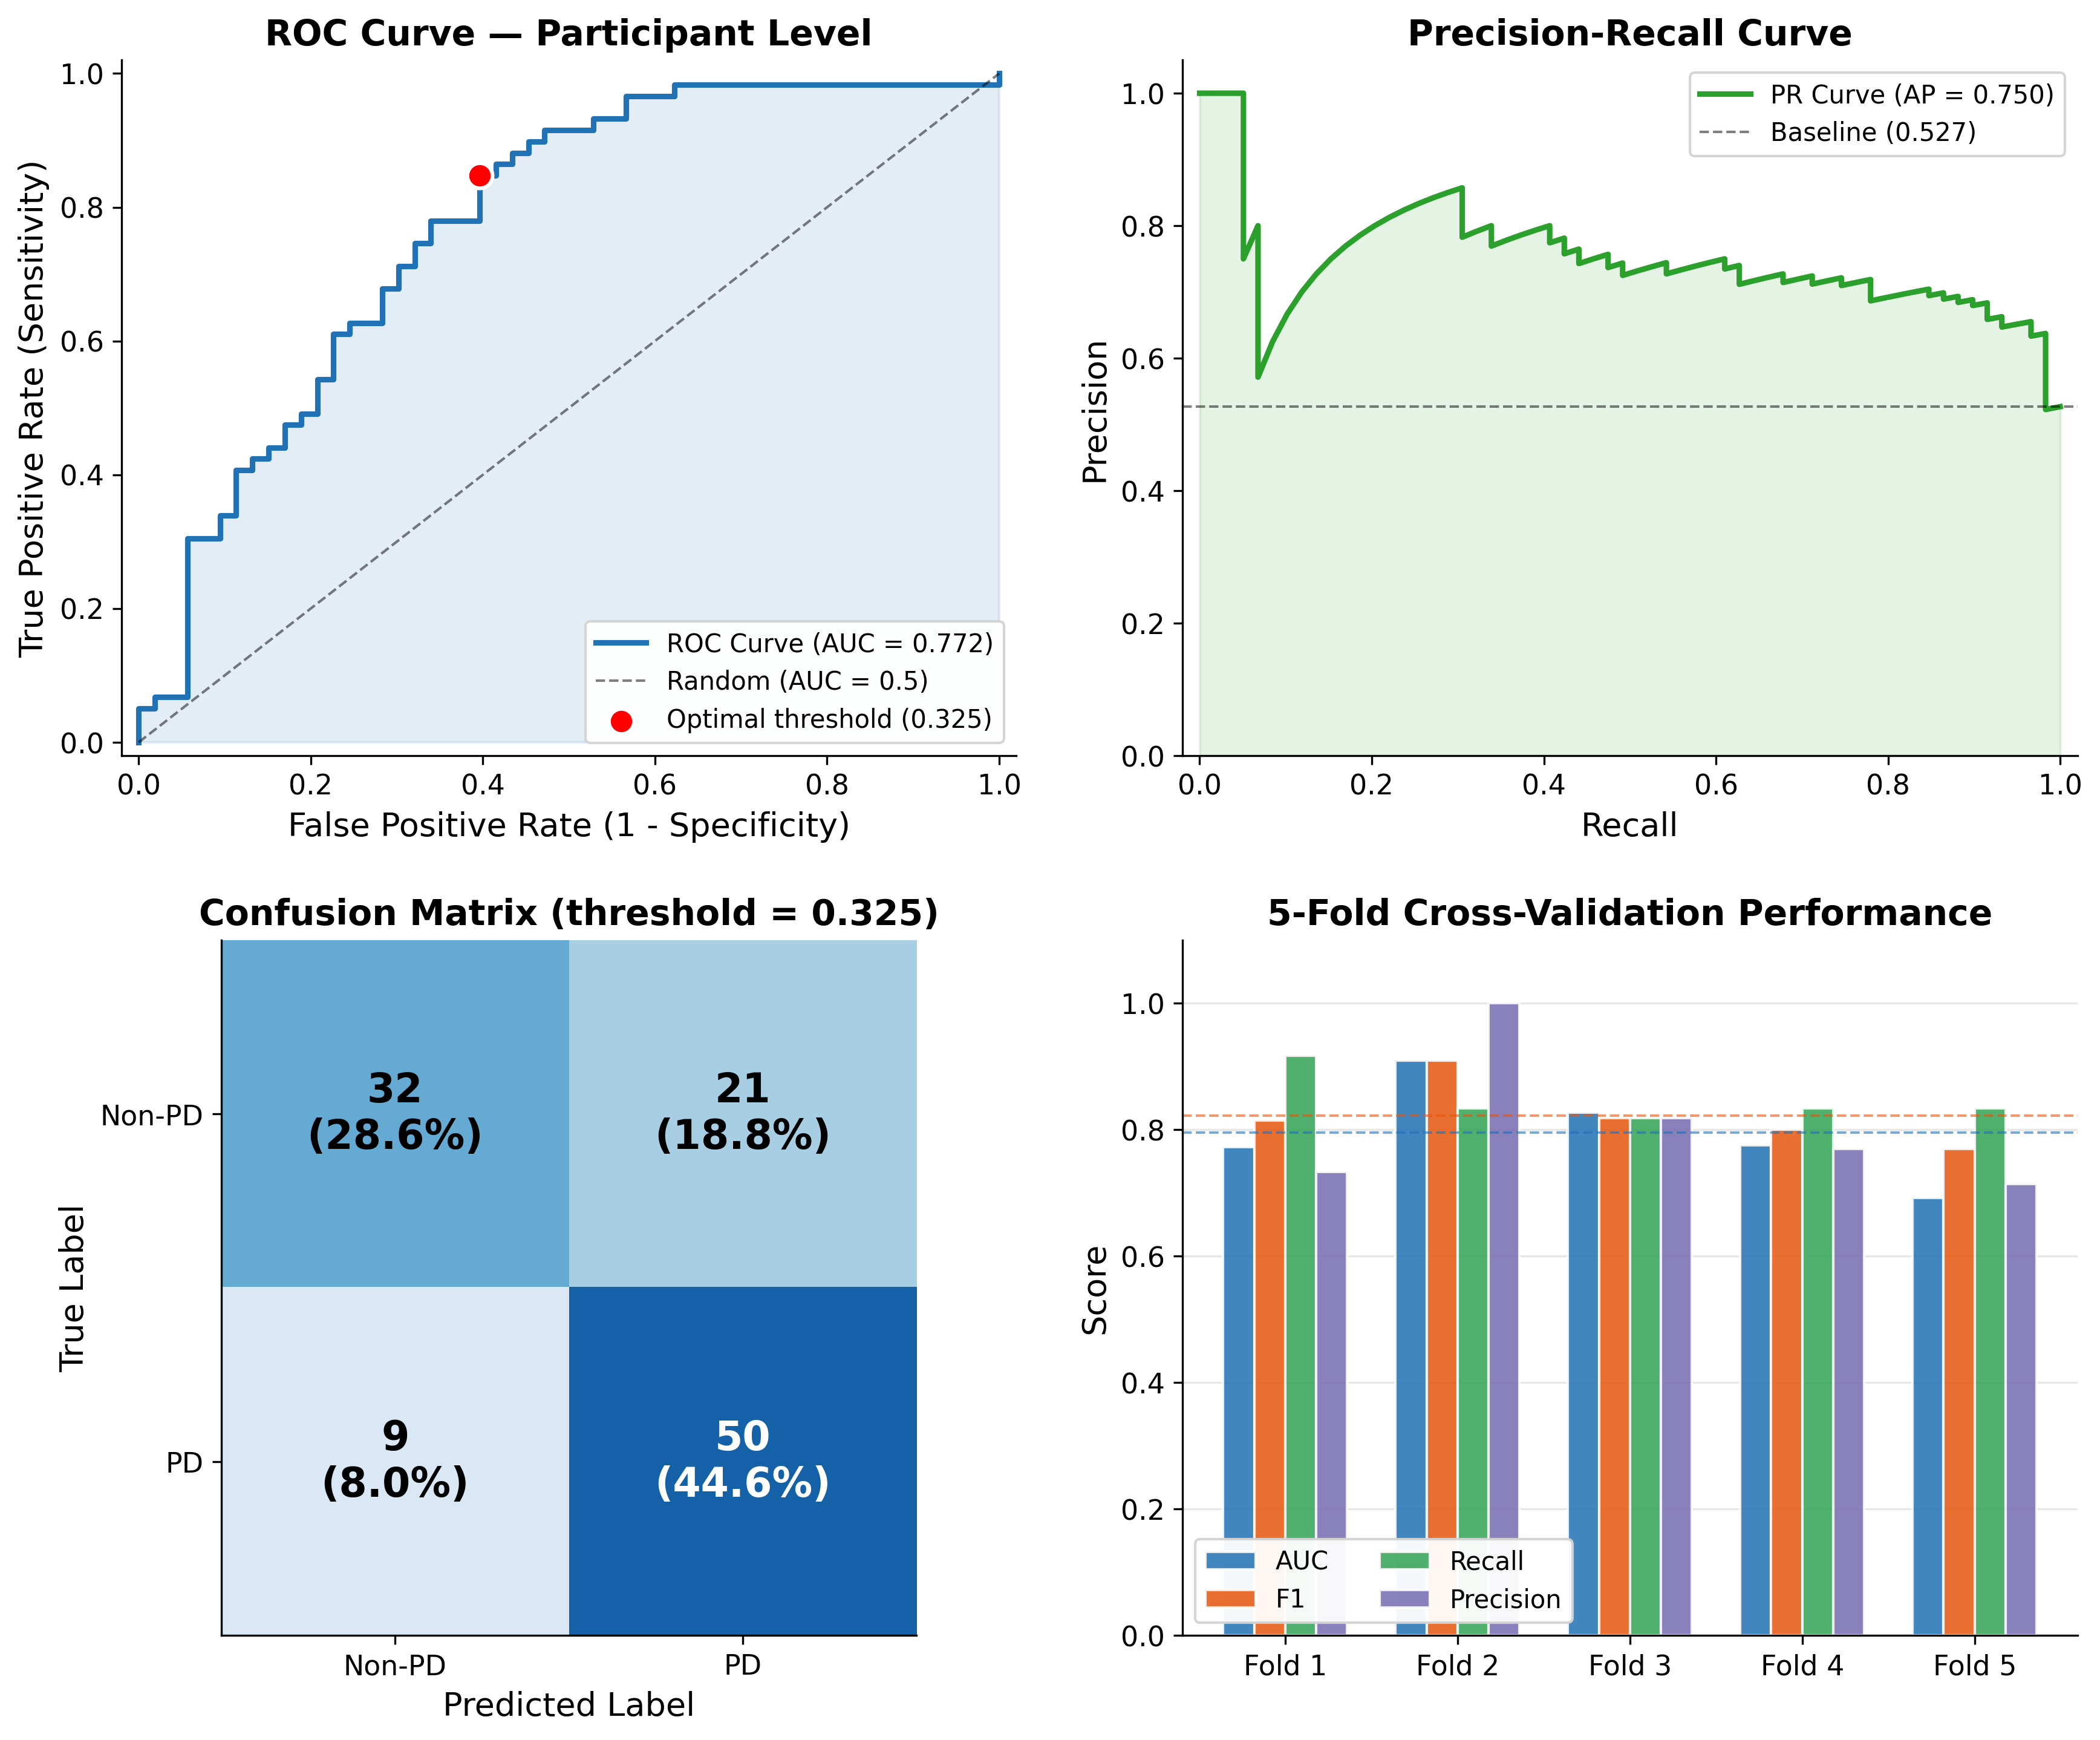

Saved: fig_pd_selected_4panel.png / .pdf


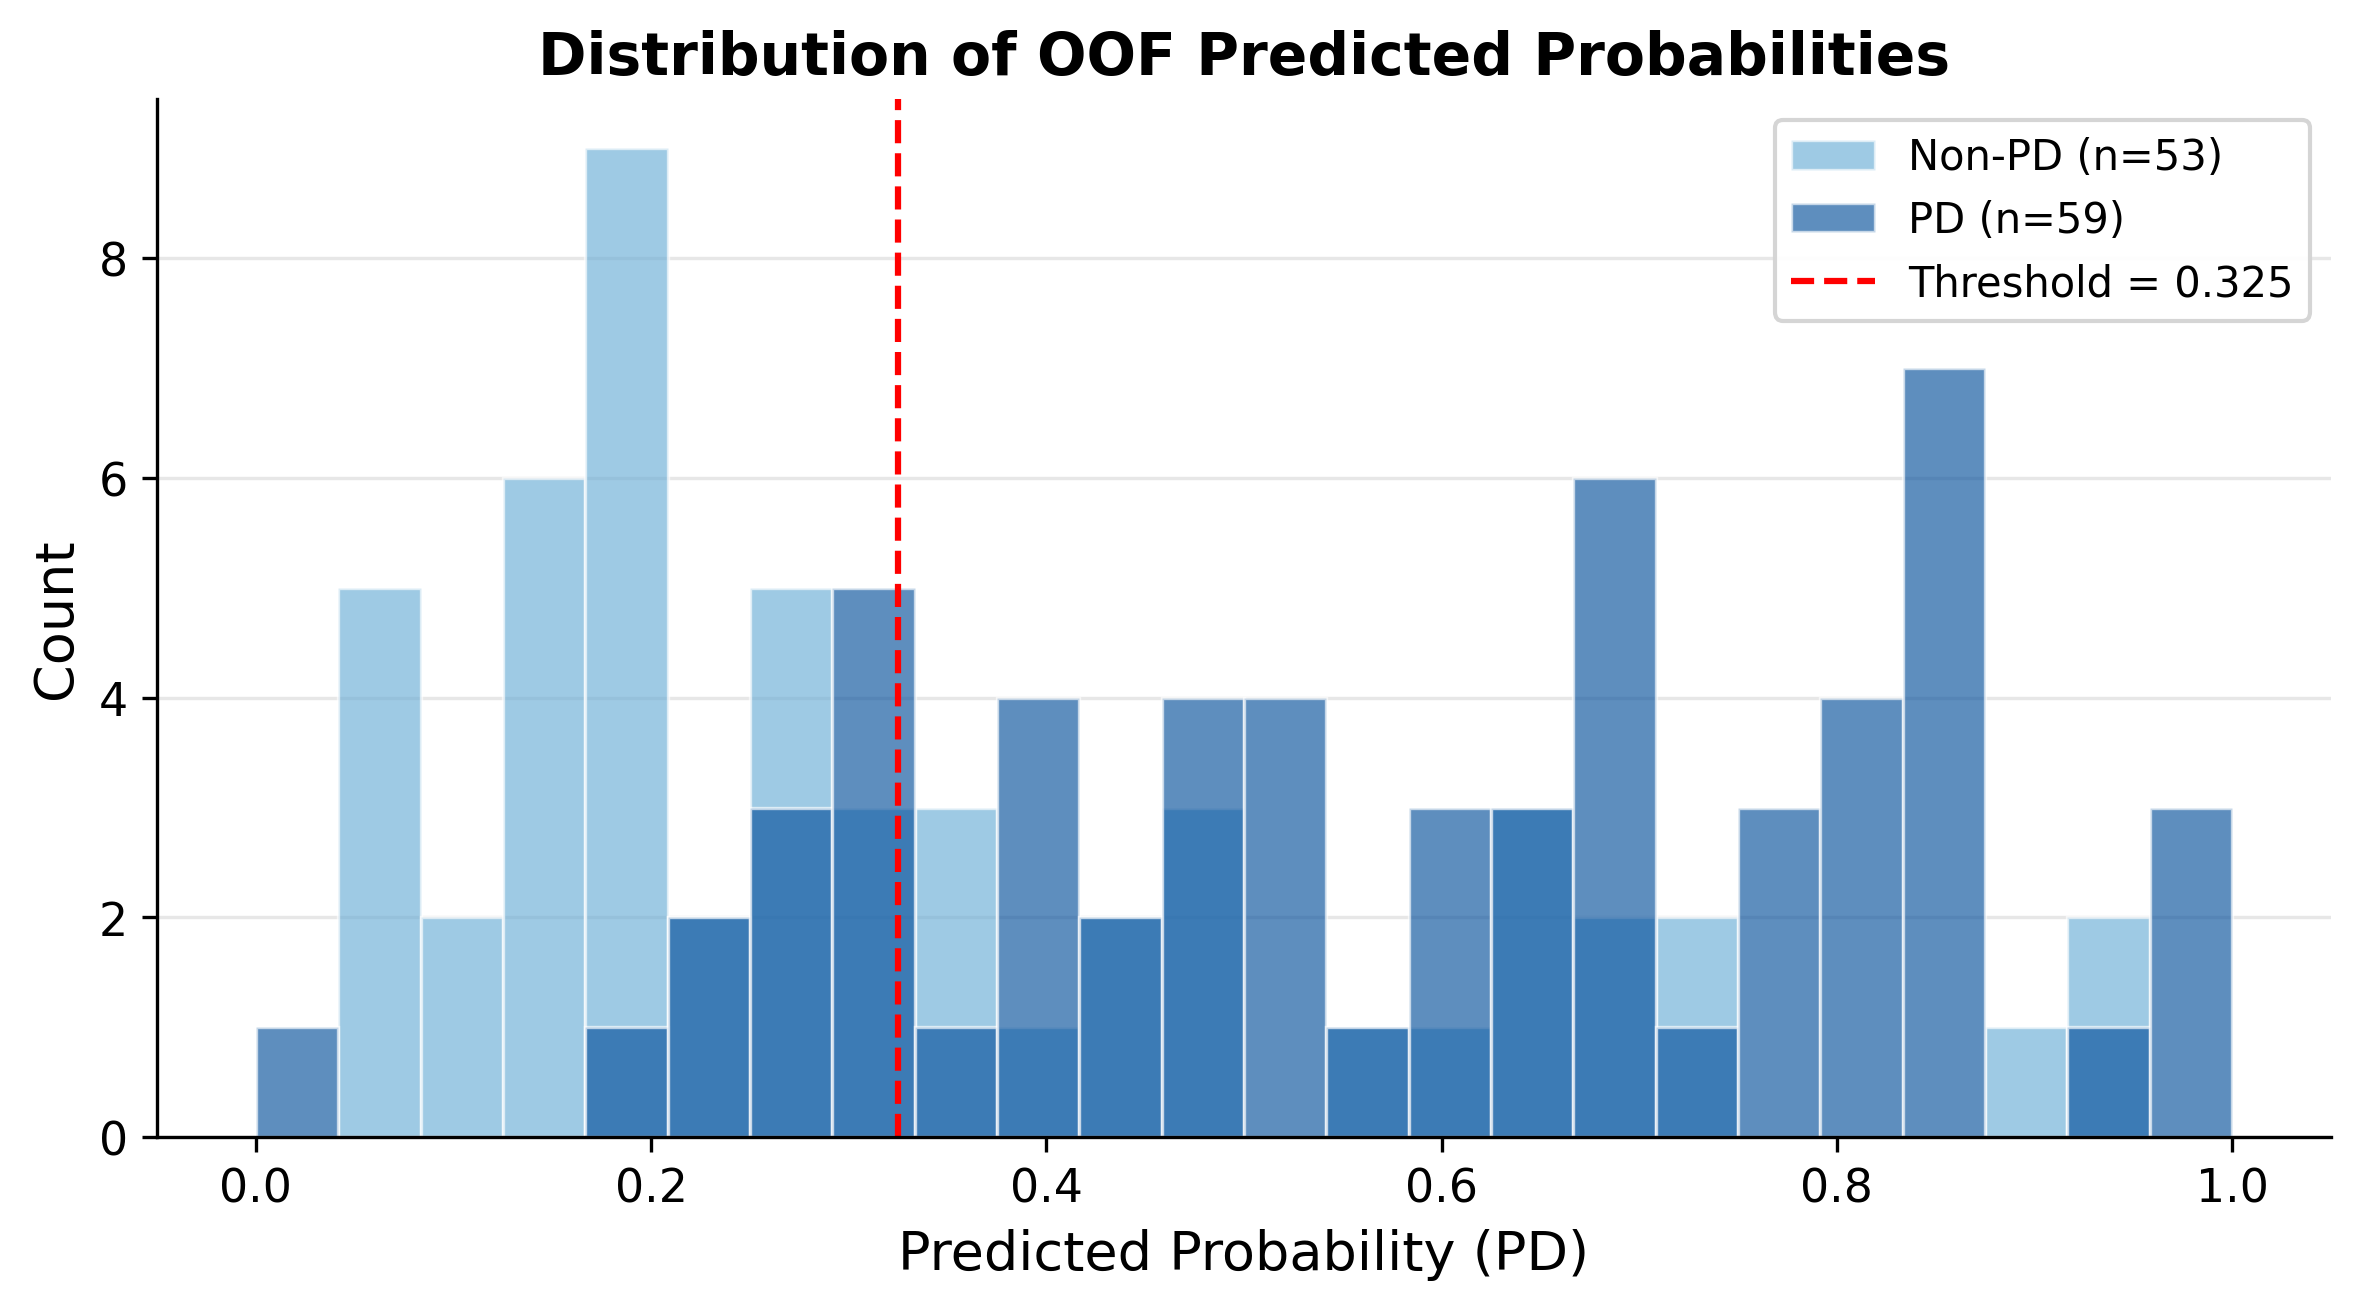

Saved: fig_pd_score_distribution.png / .pdf


In [13]:
# #12b - Publication-quality figures (PD Selected Tasks)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             f1_score, recall_score, precision_score)

matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# load saved results
data = np.load("ast_pd_selected_cv_results.npz", allow_pickle=True)
oof_probs = data['oof_probs']
oof_labels = data['oof_labels']
fold_aucs = data['fold_aucs']
fold_f1s = data['fold_f1s']
fold_recalls = data['fold_recalls']
fold_precisions = data['fold_precisions']

# OOF threshold and metrics
fpr, tpr, thresholds = roc_curve(oof_labels, oof_probs)
opt_idx = np.argmax(tpr - fpr)
oof_thresh = thresholds[opt_idx]
oof_auc = auc(fpr, tpr)
oof_preds = (oof_probs >= oof_thresh).astype(int)

pr_precision, pr_recall, _ = precision_recall_curve(oof_labels, oof_probs)
ap = average_precision_score(oof_labels, oof_probs)

cm = confusion_matrix(oof_labels, oof_preds)
tn, fp, fn, tp = cm.ravel()
total = tn + fp + fn + tp

BLUE = '#2171B5'
LIGHT_BLUE = '#6BAED6'
DARK_BLUE = '#08519C'
GREEN = '#2CA02C'

# FIGURE 3: PD 4-panel (ROC, PR, confusion matrix, per-fold bars)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# panel A: ROC
ax = axes[0, 0]
ax.plot(fpr, tpr, color=BLUE, lw=2.2, label=f'ROC Curve (AUC = {oof_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.5)')
ax.scatter(fpr[opt_idx], tpr[opt_idx], color='red', s=100, zorder=5,
           label=f'Optimal threshold ({oof_thresh:.3f})', edgecolors='white', linewidth=1.5)
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve — Participant Level', fontweight='bold')
ax.legend(loc='lower right', frameon=True, framealpha=0.95, edgecolor='lightgray')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.fill_between(fpr, tpr, alpha=0.12, color=BLUE)

# panel B: PR curve
ax = axes[0, 1]
baseline = oof_labels.sum() / len(oof_labels)
ax.plot(pr_recall, pr_precision, color=GREEN, lw=2.2, label=f'PR Curve (AP = {ap:.3f})')
ax.axhline(y=baseline, color='k', linestyle='--', lw=1, alpha=0.5, label=f'Baseline ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend(loc='upper right', frameon=True, framealpha=0.95, edgecolor='lightgray')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([0.0, 1.05])
ax.fill_between(pr_recall, pr_precision, alpha=0.12, color=GREEN)

# panel C: confusion matrix
ax = axes[1, 0]
cm_display = np.array([[tn, fp], [fn, tp]])
labels_display = np.array([
    [f'{tn}\n({tn/total:.1%})', f'{fp}\n({fp/total:.1%})'],
    [f'{fn}\n({fn/total:.1%})', f'{tp}\n({tp/total:.1%})']
])
cmap = plt.cm.Blues
im = ax.imshow(cm_display, cmap=cmap, vmin=0, vmax=total * 0.55)
for i in range(2):
    for j in range(2):
        val = cm_display[i, j]
        color = 'white' if val > total * 0.3 else 'black'
        ax.text(j, i, labels_display[i, j], ha='center', va='center',
                fontsize=16, fontweight='bold', color=color)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-PD', 'PD'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['Non-PD', 'PD'])
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'Confusion Matrix (threshold = {oof_thresh:.3f})', fontweight='bold')

# panel D: per-fold bars
ax = axes[1, 1]
x = np.arange(5)
width = 0.18
ax.bar(x - 1.5*width, fold_aucs, width, color=BLUE, alpha=0.85, label='AUC', edgecolor='white')
ax.bar(x - 0.5*width, fold_f1s, width, color='#E6550D', alpha=0.85, label='F1', edgecolor='white')
ax.bar(x + 0.5*width, fold_recalls, width, color='#31A354', alpha=0.85, label='Recall', edgecolor='white')
ax.bar(x + 1.5*width, fold_precisions, width, color='#756BB1', alpha=0.85, label='Precision', edgecolor='white')
ax.axhline(y=np.mean(fold_aucs), color=BLUE, linestyle='--', alpha=0.6, lw=1)
ax.axhline(y=np.mean(fold_f1s), color='#E6550D', linestyle='--', alpha=0.6, lw=1)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylabel('Score')
ax.set_title('5-Fold Cross-Validation Performance', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower left', frameon=True, framealpha=0.95, edgecolor='lightgray', ncol=2)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout(pad=2.0)
fig.savefig('fig_pd_selected_4panel.png', dpi=300, facecolor='white', bbox_inches='tight')
fig.savefig('fig_pd_selected_4panel.pdf', facecolor='white', bbox_inches='tight')
plt.show()
print("Saved: fig_pd_selected_4panel.png / .pdf")

# FIGURE: OOF score distribution (PD vs Non-PD)

fig2, ax2 = plt.subplots(figsize=(8, 4.5))

pd_scores = oof_probs[oof_labels == 1]
ctrl_scores = oof_probs[oof_labels == 0]

bins = np.linspace(0, 1, 25)
ax2.hist(ctrl_scores, bins=bins, alpha=0.65, color=LIGHT_BLUE, edgecolor='white',
         linewidth=0.8, label=f'Non-PD (n={len(ctrl_scores)})')
ax2.hist(pd_scores, bins=bins, alpha=0.65, color=DARK_BLUE, edgecolor='white',
         linewidth=0.8, label=f'PD (n={len(pd_scores)})')
ax2.axvline(x=oof_thresh, color='red', linestyle='--', lw=1.5,
            label=f'Threshold = {oof_thresh:.3f}')
ax2.set_xlabel('Predicted Probability (PD)')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of OOF Predicted Probabilities', fontweight='bold')
ax2.legend(frameon=True, framealpha=0.95, edgecolor='lightgray')
ax2.yaxis.grid(True, alpha=0.3)
ax2.set_axisbelow(True)

plt.tight_layout()
fig2.savefig('fig_pd_score_distribution.png', dpi=300, facecolor='white', bbox_inches='tight')
fig2.savefig('fig_pd_score_distribution.pdf', facecolor='white', bbox_inches='tight')
plt.show()
print("Saved: fig_pd_score_distribution.png / .pdf")

# Metadata merge and Eval

In [15]:
# #13 - Load saved OOF predictions and merge with phenotype metadata

import numpy as np
import pandas as pd

# load saved OOF from Cell #11
data = np.load("ast_pd_selected_cv_results.npz", allow_pickle=True)
oof_probs = data['oof_probs']
oof_labels = data['oof_labels']
participant_ids = data['participant_ids']

# build dataframe of AST predictions
ast_df = pd.DataFrame({
    'participant_id': participant_ids,
    'ast_prob': oof_probs,
    'parkinsons_label': oof_labels.astype(int)
})

# load phenotype and extract metadata
PHEN = '/data0/b2ai-voice/2.0.0/phenotype.tsv'
pheno = pd.read_csv(PHEN, sep='\t')

# age and sex
meta_cols = ['participant_id', 'age', 'sex_at_birth']
meta = pheno[meta_cols].copy()

# merge
merged = ast_df.merge(meta, on='participant_id', how='inner')
merged['sex_binary'] = (merged['sex_at_birth'] == 'Male').astype(int)
merged['age'] = pd.to_numeric(merged['age'], errors='coerce')
merged = merged.dropna(subset=['age', 'sex_binary'])

print(f"Merged participants: {len(merged)}")
print(f"PD: {merged['parkinsons_label'].sum()}, Non-PD: {(merged['parkinsons_label'] == 0).sum()}")
print(f"Age range: {merged['age'].min():.0f} - {merged['age'].max():.0f}")
print(f"Sex (male): {merged['sex_binary'].sum()} ({merged['sex_binary'].mean():.1%})")
print(merged[['participant_id', 'ast_prob', 'parkinsons_label', 'age', 'sex_binary']].head())

Merged participants: 112
PD: 59, Non-PD: 53
Age range: 20 - 85
Sex (male): 68 (60.7%)
  participant_id  ast_prob  parkinsons_label   age  sex_binary
0       004d42e9  0.083325                 0  75.0           0
1       01401050  0.355747                 0  74.0           1
2       0581355f  0.781103                 1  79.0           1
3       07929b7b  0.283583                 0  62.0           0
4       0842e76f  0.171871                 0  78.0           0


In [16]:
# #14 - Metadata-only logistic regression + soft voting ensemble
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, roc_curve

# prepare metadata features from Cell #13
X_meta = merged[['age', 'sex_binary']].values
y_meta = merged['parkinsons_label'].values
ast_probs_aligned = merged['ast_prob'].values

# metadata-only logistic regression with 5-fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_oof_probs = np.zeros(len(y_meta))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_meta, y_meta)):
    X_tr, X_val = X_meta[train_idx], X_meta[val_idx]
    y_tr = y_meta[train_idx]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
    lr.fit(X_tr, y_tr)

    meta_oof_probs[val_idx] = lr.predict_proba(X_val)[:, 1]

# metadata-only OOF metrics
meta_auc = roc_auc_score(y_meta, meta_oof_probs)
fpr, tpr, thresholds = roc_curve(y_meta, meta_oof_probs)
opt_idx = np.argmax(tpr - fpr)
meta_thresh = thresholds[opt_idx]
meta_preds = (meta_oof_probs >= meta_thresh).astype(int)

print("Metadata-only (age + sex) OOF results:")
print(f"  AUC:       {meta_auc:.4f}")
print(f"  F1:        {f1_score(y_meta, meta_preds, zero_division=0):.4f} (threshold={meta_thresh:.3f})")
print(f"  Recall:    {recall_score(y_meta, meta_preds, zero_division=0):.4f}")
print(f"  Precision: {precision_score(y_meta, meta_preds, zero_division=0):.4f}")

# soft voting: 0.5 * AST + 0.5 * metadata
combined_probs = 0.5 * ast_probs_aligned + 0.5 * meta_oof_probs

combined_auc = roc_auc_score(y_meta, combined_probs)
fpr, tpr, thresholds = roc_curve(y_meta, combined_probs)
opt_idx = np.argmax(tpr - fpr)
combined_thresh = thresholds[opt_idx]
combined_preds = (combined_probs >= combined_thresh).astype(int)

print("\nAST + Metadata (soft voting) OOF results:")
print(f"  AUC:       {combined_auc:.4f}")
print(f"  F1:        {f1_score(y_meta, combined_preds, zero_division=0):.4f} (threshold={combined_thresh:.3f})")
print(f"  Recall:    {recall_score(y_meta, combined_preds, zero_division=0):.4f}")
print(f"  Precision: {precision_score(y_meta, combined_preds, zero_division=0):.4f}")

# AST-only metrics (on the same subset that has metadata)
ast_auc = roc_auc_score(y_meta, ast_probs_aligned)
fpr, tpr, thresholds = roc_curve(y_meta, ast_probs_aligned)
opt_idx = np.argmax(tpr - fpr)
ast_thresh = thresholds[opt_idx]
ast_preds = (ast_probs_aligned >= ast_thresh).astype(int)

print("\nAST-only (same subset) OOF results:")
print(f"  AUC:       {ast_auc:.4f}")
print(f"  F1:        {f1_score(y_meta, ast_preds, zero_division=0):.4f} (threshold={ast_thresh:.3f})")
print(f"  Recall:    {recall_score(y_meta, ast_preds, zero_division=0):.4f}")
print(f"  Precision: {precision_score(y_meta, ast_preds, zero_division=0):.4f}")

# summary table
print("\nComparison table:")
print(f"  {'Model':<25} {'AUC':<10} {'F1':<10} {'Threshold':<10}")
print(f"  {'AST only':<25} {ast_auc:<10.4f} {f1_score(y_meta, ast_preds, zero_division=0):<10.4f} {ast_thresh:<10.3f}")
print(f"  {'Metadata only':<25} {meta_auc:<10.4f} {f1_score(y_meta, meta_preds, zero_division=0):<10.4f} {meta_thresh:<10.3f}")
print(f"  {'AST + Metadata':<25} {combined_auc:<10.4f} {f1_score(y_meta, combined_preds, zero_division=0):<10.4f} {combined_thresh:<10.3f}")

Metadata-only (age + sex) OOF results:
  AUC:       0.5919
  F1:        0.7613 (threshold=0.369)
  Recall:    1.0000
  Precision: 0.6146

AST + Metadata (soft voting) OOF results:
  AUC:       0.7979
  F1:        0.7692 (threshold=0.471)
  Recall:    0.7627
  Precision: 0.7759

AST-only (same subset) OOF results:
  AUC:       0.7720
  F1:        0.7692 (threshold=0.325)
  Recall:    0.8475
  Precision: 0.7042

Comparison table:
  Model                     AUC        F1         Threshold 
  AST only                  0.7720     0.7692     0.325     
  Metadata only             0.5919     0.7613     0.369     
  AST + Metadata            0.7979     0.7692     0.471     


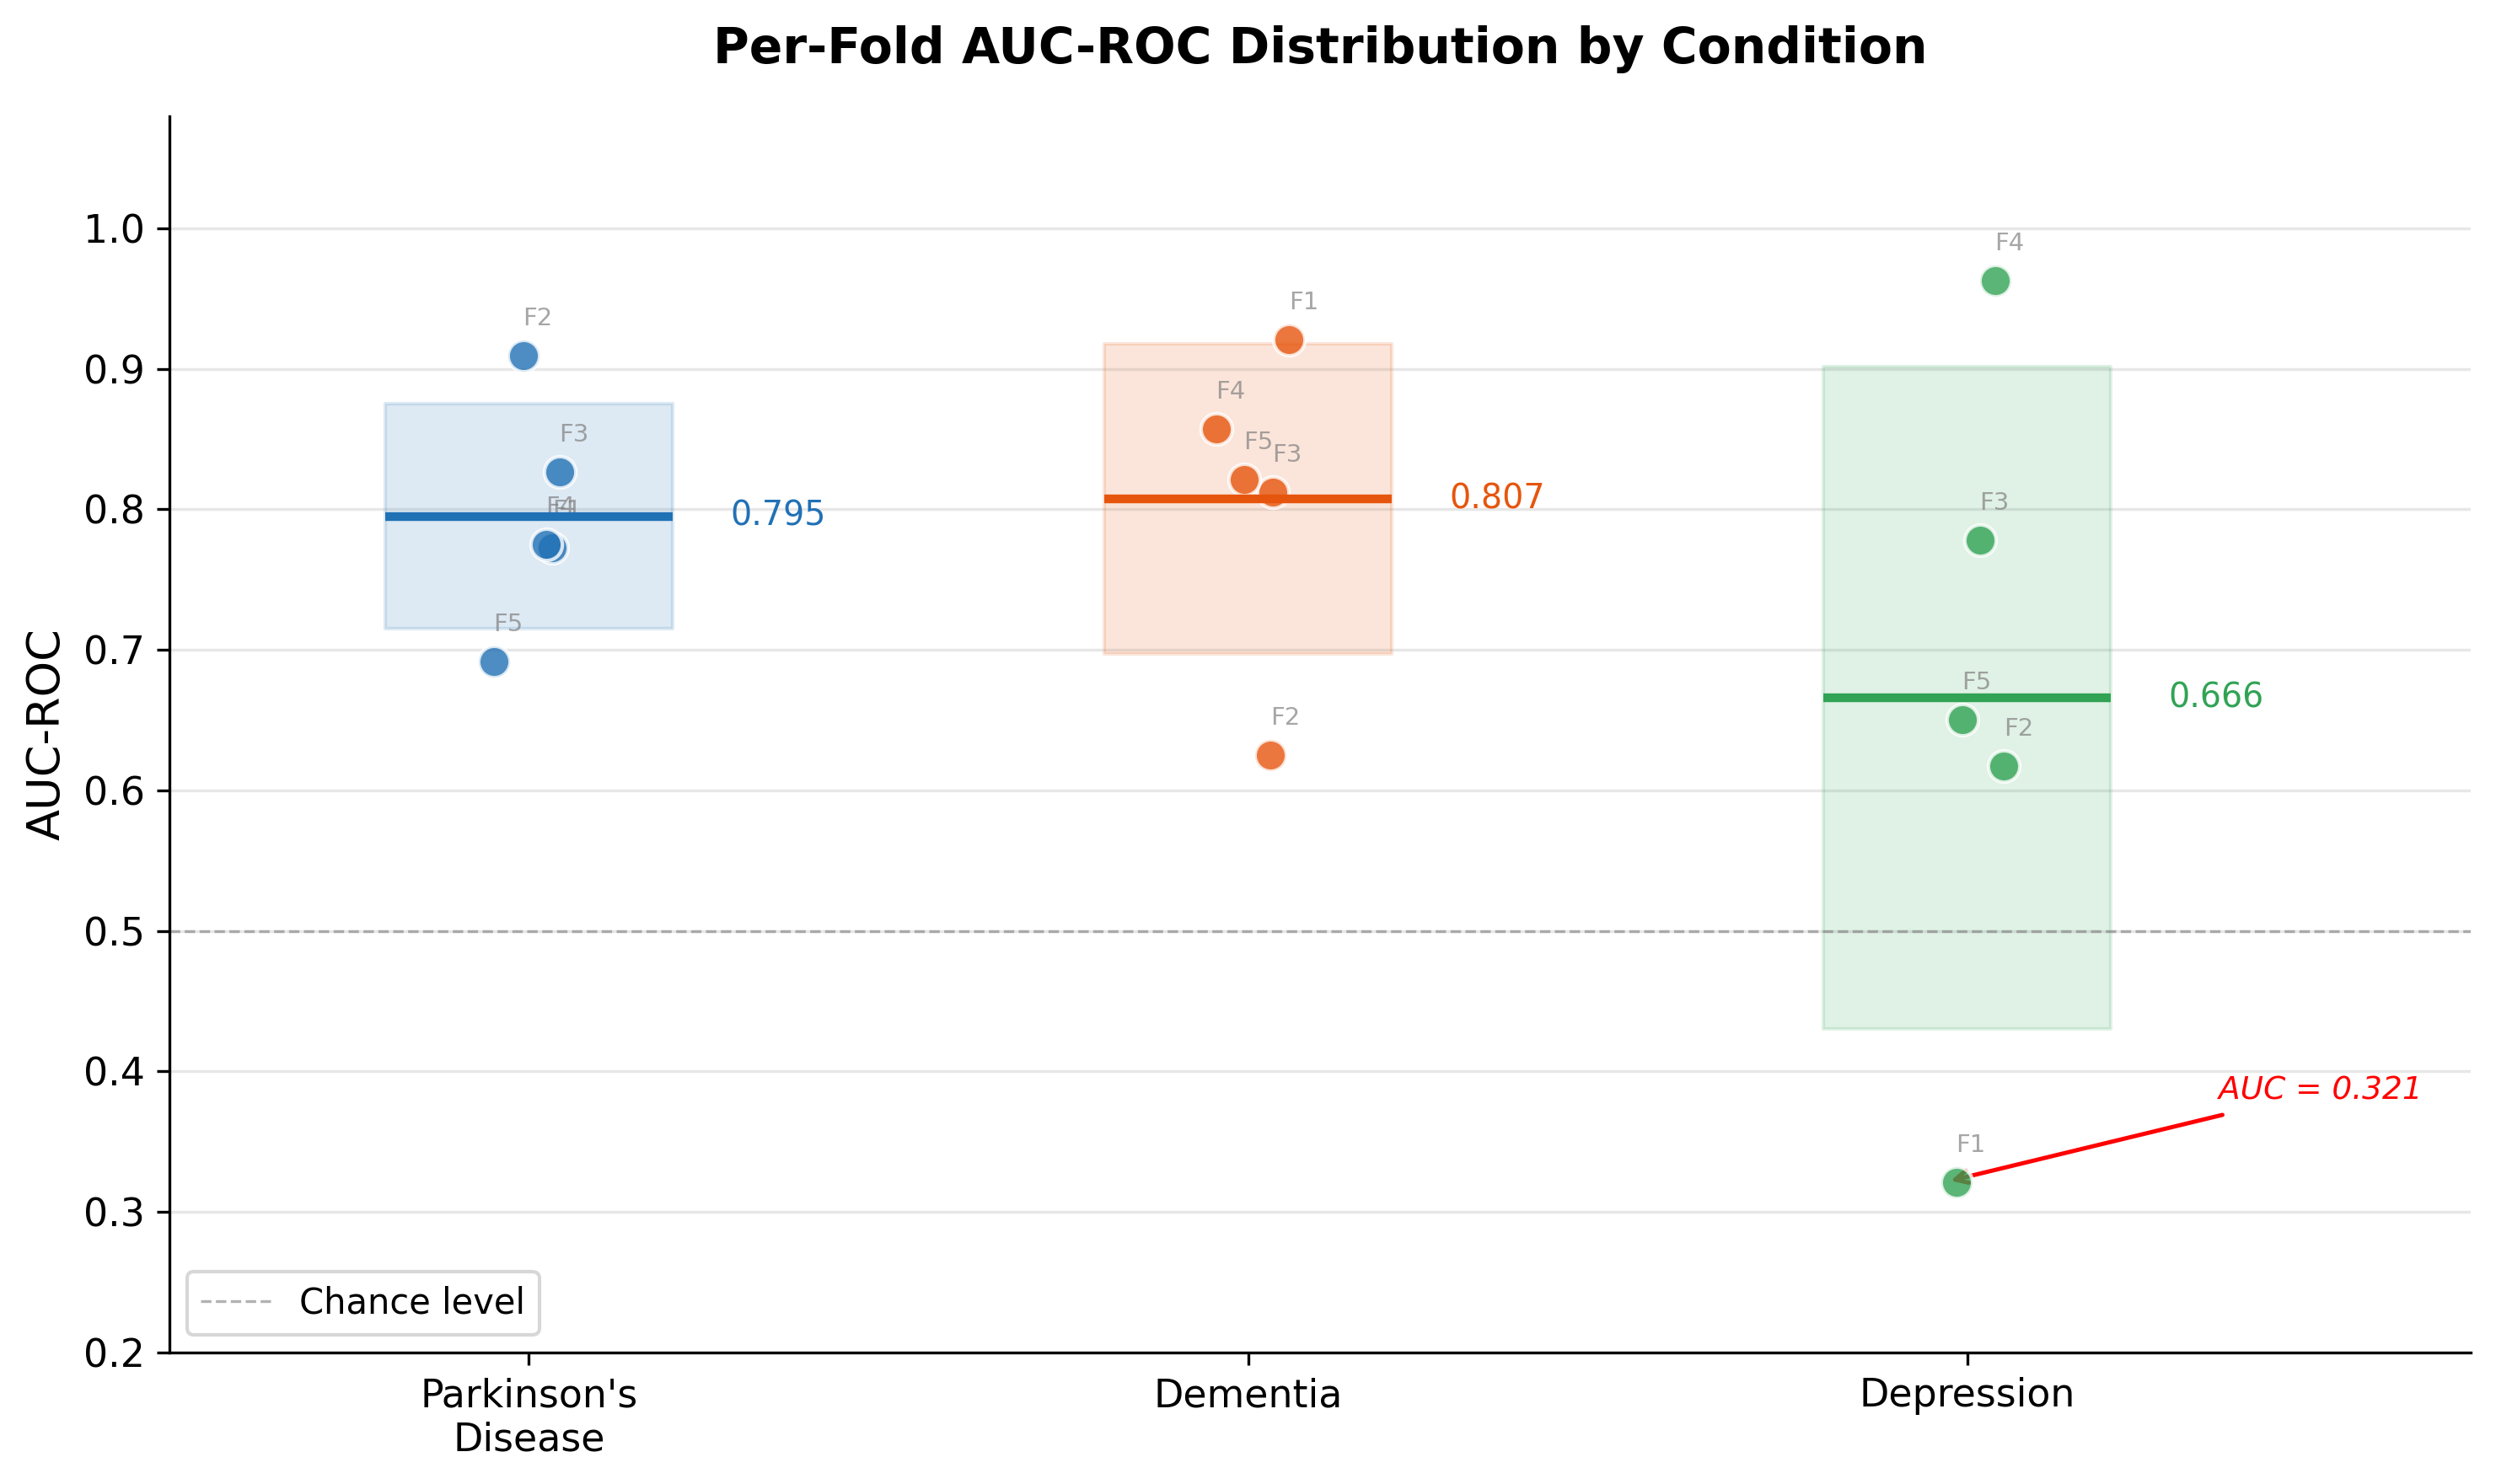

Saved: fig_fold_auc_distribution.png / .pdf

AUC difference: +0.120 (was +0.148, now +0.120)
Precision difference: -0.227 (was -0.235, now -0.227)


In [20]:
# Regenerate figures with corrected PD numbers
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# corrected PD fold values
pd_aucs = [0.7727, 0.9091, 0.8264, 0.7750, 0.6917]
pd_f1s = [0.8148, 0.9091, 0.8182, 0.8000, 0.7692]
pd_recalls = [0.9167, 0.8333, 0.8182, 0.8333, 0.8333]
pd_precs = [0.7333, 1.0000, 0.8182, 0.7692, 0.7143]

# dementia and depression unchanged
dem_aucs = [0.9206, 0.625, 0.8125, 0.8571, 0.8214]
dep_aucs = [0.3210, 0.6173, 0.7778, 0.9630, 0.650]

# all-tasks PD unchanged
all_pd_aucs = [0.9470, 0.9524, 0.9243, 0.7873, 0.9649]
all_pd_f1s = [0.7742, 0.7742, 0.7273, 0.5455, 0.7500]
all_pd_recalls = [1.000, 0.9231, 1.000, 0.750, 1.000]
all_pd_precs = [0.6316, 0.6667, 0.5714, 0.4286, 0.600]

# FIGURE: Per-Fold AUC Distribution by Condition (strip plot)

fig1, ax1 = plt.subplots(figsize=(10, 6))

COLOR_PD = '#2171B5'
COLOR_DEM = '#E6550D'
COLOR_DEP = '#31A354'

all_aucs = [pd_aucs, dem_aucs, dep_aucs]
colors = [COLOR_PD, COLOR_DEM, COLOR_DEP]
cond_labels = ["Parkinson's\nDisease", 'Dementia', 'Depression']

rng = np.random.default_rng(42)
for i, (aucs_cond, color) in enumerate(zip(all_aucs, colors)):
    aucs_arr = np.array(aucs_cond)
    jitter = rng.uniform(-0.06, 0.06, len(aucs_arr))

    # SD shading
    m = np.mean(aucs_arr)
    sd = np.std(aucs_arr, ddof=1)
    ax1.fill_between([i - 0.2, i + 0.2], m - sd, m + sd,
                     color=color, alpha=0.15, zorder=2)

    # mean line
    ax1.hlines(m, i - 0.2, i + 0.2, color=color, linewidth=2.5, zorder=6)

    # individual fold points
    ax1.scatter([i + j for j in jitter], aucs_arr, color=color, s=80,
                zorder=5, alpha=0.8, edgecolors='white', linewidth=1)

    # mean label
    ax1.text(i + 0.28, m, f'{m:.3f}', va='center', fontsize=9.5,
             fontweight='medium', color=color)

    # fold labels
    for k, v in enumerate(aucs_arr):
        ax1.text(i + jitter[k] + 0.02, v + 0.018, f'F{k+1}', fontsize=7,
                 ha='center', va='bottom', color='gray', alpha=0.7)

# annotate depression below-chance fold
dep_min = np.argmin(dep_aucs)
dep_jitter = rng.uniform(-0.06, 0.06, 5)
ax1.annotate(f'AUC = {dep_aucs[dep_min]:.3f}',
             xy=(2 + dep_jitter[dep_min], dep_aucs[dep_min]),
             xytext=(2.35, 0.38),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.2),
             fontsize=9, color='red', fontstyle='italic')

ax1.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Chance level')
ax1.set_xticks(range(3))
ax1.set_xticklabels(cond_labels)
ax1.set_ylabel('AUC-ROC')
ax1.set_title('Per-Fold AUC-ROC Distribution by Condition', fontweight='bold', pad=15)
ax1.set_ylim(0.2, 1.08)
ax1.set_xlim(-0.5, 2.7)
ax1.yaxis.grid(True, alpha=0.3)
ax1.set_axisbelow(True)
ax1.legend(loc='lower left', frameon=True, framealpha=0.9, edgecolor='lightgray')

plt.tight_layout()
fig1.savefig('fig_fold_auc_distribution.png', dpi=300, facecolor='white', bbox_inches='tight')
fig1.savefig('fig_fold_auc_distribution.pdf', facecolor='white', bbox_inches='tight')
plt.show()
print("Saved: fig_fold_auc_distribution.png / .pdf")


# print the difference values for verification
print(f"\nAUC difference: +{auc_diff:.3f} (was +0.148, now +{auc_diff:.3f})")
print(f"Precision difference: {prec_diff:.3f} (was -0.235, now {prec_diff:.3f})")

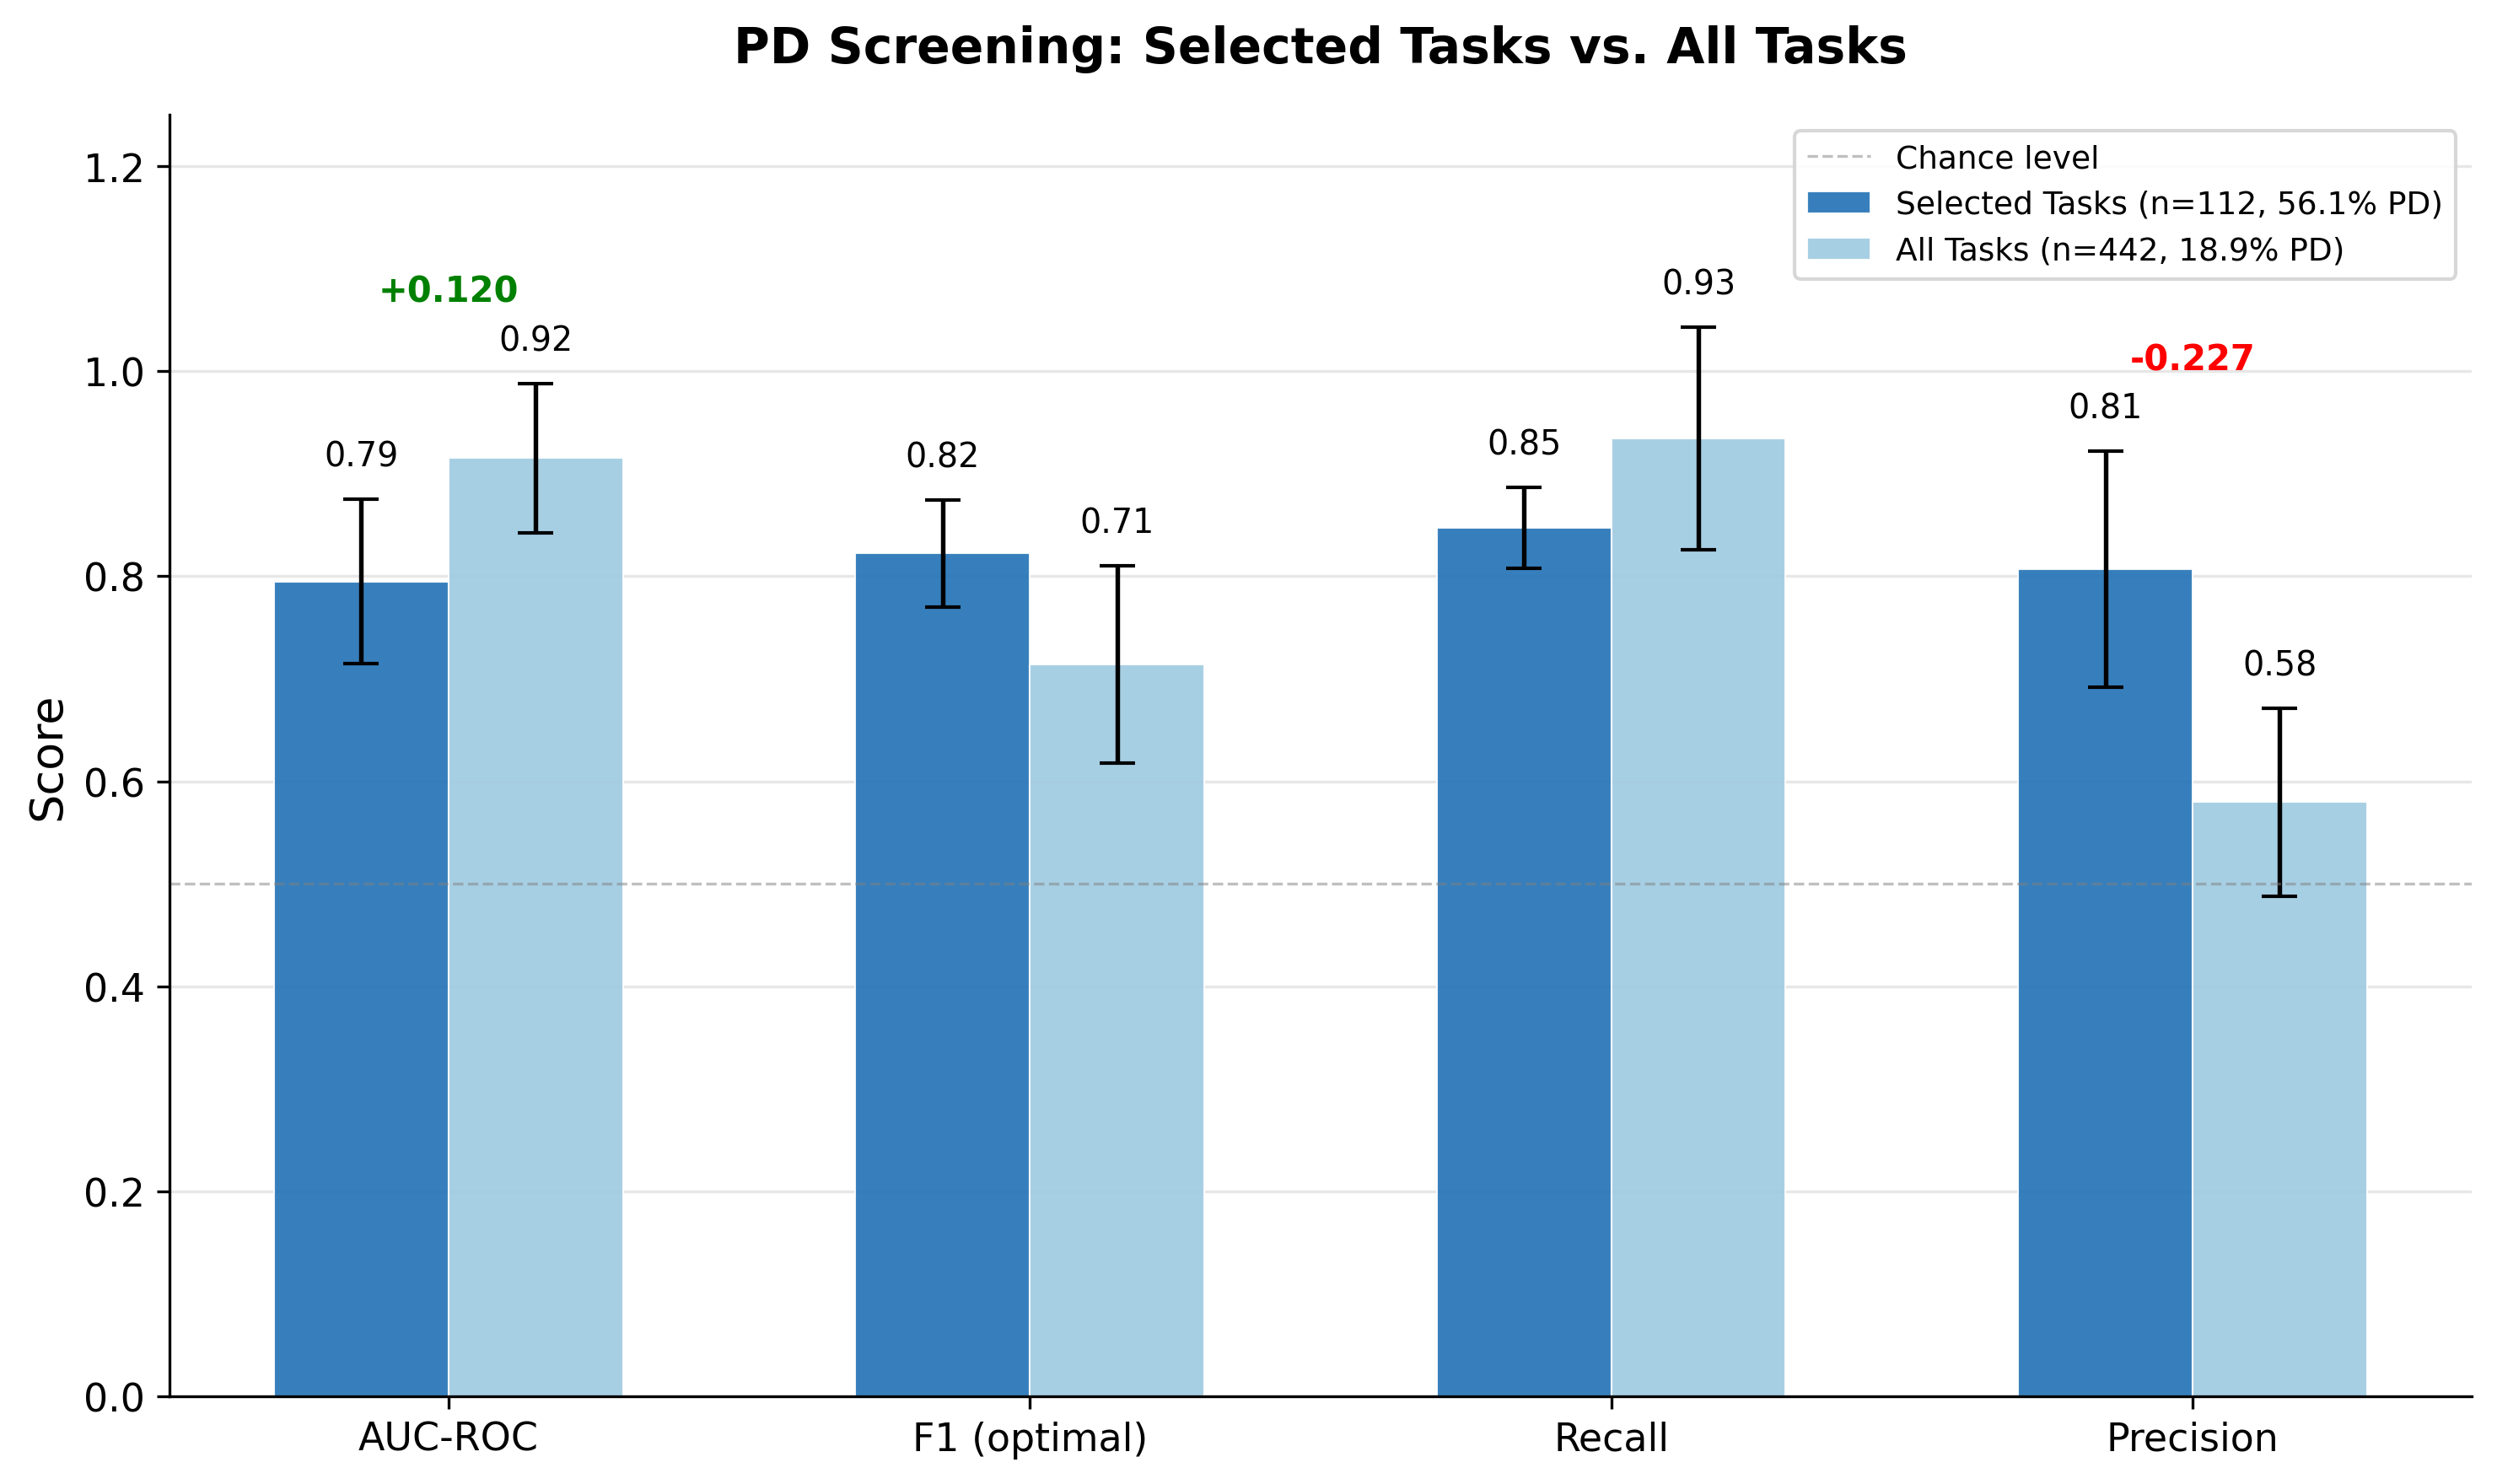

Saved: fig_task_selection_comparison.png / .pdf
AUC diff: +0.120, Precision diff: -0.227


In [21]:
# Regenerate task selection figure with labels above error bars
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# corrected PD selected tasks
pd_aucs = [0.7727, 0.9091, 0.8264, 0.7750, 0.6917]
pd_f1s = [0.8148, 0.9091, 0.8182, 0.8000, 0.7692]
pd_recalls = [0.9167, 0.8333, 0.8182, 0.8333, 0.8333]
pd_precs = [0.7333, 1.0000, 0.8182, 0.7692, 0.7143]

# all tasks unchanged
all_pd_aucs = [0.9470, 0.9524, 0.9243, 0.7873, 0.9649]
all_pd_f1s = [0.7742, 0.7742, 0.7273, 0.5455, 0.7500]
all_pd_recalls = [1.000, 0.9231, 1.000, 0.750, 1.000]
all_pd_precs = [0.6316, 0.6667, 0.5714, 0.4286, 0.600]

metrics_names = ['AUC-ROC', 'F1 (optimal)', 'Recall', 'Precision']

sel_means = [np.mean(pd_aucs), np.mean(pd_f1s), np.mean(pd_recalls), np.mean(pd_precs)]
sel_stds = [np.std(pd_aucs, ddof=1), np.std(pd_f1s, ddof=1), np.std(pd_recalls, ddof=1), np.std(pd_precs, ddof=1)]

all_means = [np.mean(all_pd_aucs), np.mean(all_pd_f1s), np.mean(all_pd_recalls), np.mean(all_pd_precs)]
all_stds = [np.std(all_pd_aucs, ddof=1), np.std(all_pd_f1s, ddof=1), np.std(all_pd_recalls, ddof=1), np.std(all_pd_precs, ddof=1)]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(metrics_names))
w = 0.30

DARK = '#2171B5'
LIGHT = '#9ECAE1'

bars1 = ax.bar(x - w/2, sel_means, w, yerr=sel_stds, capsize=5,
               color=DARK, edgecolor='white', linewidth=0.5,
               label='Selected Tasks (n=112, 56.1% PD)', alpha=0.9,
               error_kw={'linewidth': 1.3})
bars2 = ax.bar(x + w/2, all_means, w, yerr=all_stds, capsize=5,
               color=LIGHT, edgecolor='white', linewidth=0.5,
               label='All Tasks (n=442, 18.9% PD)', alpha=0.9,
               error_kw={'linewidth': 1.3})

# place labels above the error bar cap (mean + std + offset)
for bar, m, s in zip(bars1, sel_means, sel_stds):
    ax.text(bar.get_x() + bar.get_width()/2., m + s + 0.025,
            f'{m:.2f}', ha='center', va='bottom', fontsize=9.5, fontweight='medium')

for bar, m, s in zip(bars2, all_means, all_stds):
    ax.text(bar.get_x() + bar.get_width()/2., m + s + 0.025,
            f'{m:.2f}', ha='center', va='bottom', fontsize=9.5, fontweight='medium')

# difference annotations
auc_diff = all_means[0] - sel_means[0]
prec_diff = all_means[3] - sel_means[3]

# position above the higher error bar cap
auc_top = max(sel_means[0] + sel_stds[0], all_means[0] + all_stds[0]) + 0.08
prec_top = max(sel_means[3] + sel_stds[3], all_means[3] + all_stds[3]) + 0.08

ax.annotate(f'+{auc_diff:.3f}', xy=(0, auc_top),
            fontsize=10, fontweight='bold', color='green', ha='center')
ax.annotate(f'{prec_diff:.3f}', xy=(3, prec_top),
            fontsize=10, fontweight='bold', color='red', ha='center')

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Chance level')
ax.set_ylabel('Score')
ax.set_title('PD Screening: Selected Tasks vs. All Tasks', fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.25)
ax.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='lightgray', fontsize=9)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig('fig_task_selection_comparison.png', dpi=300, facecolor='white', bbox_inches='tight')
fig.savefig('fig_task_selection_comparison.pdf', facecolor='white', bbox_inches='tight')
plt.show()
print("Saved: fig_task_selection_comparison.png / .pdf")
print(f"AUC diff: +{auc_diff:.3f}, Precision diff: {prec_diff:.3f}")

In [1]:
pip freeze | grep -iE "torch|torchaudio|transformers|numpy|pandas|scikit-learn|scipy|matplotlib|tqdm|pyarrow" > requirements.txt

Note: you may need to restart the kernel to use updated packages.
